# IPL Cricket Data Analytics Project - Introduction

## What is IPL?

The **Indian Premier League (IPL)** is a professional Twenty20 cricket league in India. Founded in 2008, the IPL has become one of the most popular and competitive cricket leagues in the world. With its fast-paced matches, global talent pool, and massive audience engagement, the IPL has revolutionized modern cricket. The league features eight franchises representing different cities and regions of India, competing annually to claim the championship title.

## Project Overview

**IPL Data Analytics** is a comprehensive data analysis project focused on analyzing historical IPL match data spanning from 2008 to 2022. This project performs detailed statistical analysis, exploratory data visualization, and predictive modeling on IPL cricket data to uncover patterns, trends, and insights about team performance, winning margins, and match outcomes. Through data-driven analysis, we can better understand the factors influencing match results and make informed predictions about future game scenarios.

## Project Objectives

The primary objectives of this IPL Data Analytics project include:

1. **Data Understanding & Exploration**: Analyze the structure and characteristics of IPL match data collected over 15 seasons
2. **Pattern Discovery**: Identify trends in winning teams, margins of victory, and performance patterns across seasons
3. **Predictive Modeling**: Build regression and classification models to predict match outcomes and winning margins
4. **Performance Insights**: Generate visualizations and reports that provide actionable insights for stakeholders
5. **Data Quality Assessment**: Handle missing data, detect outliers, and ensure data integrity for reliable analysis

## Dataset Overview

This project utilizes two primary datasets:

- **IPL_Matches_2008_2022.csv**: Contains comprehensive match-level data including team information, winning teams, margins, win types, and match details
- **IPL_Ball_by_Ball_2008_2022.csv**: Provides granular ball-by-ball data for detailed match analysis and performance metrics

The datasets include both quantitative features (match numbers, seasons, margins) and qualitative features (team names, win types) that enable comprehensive analysis.

## Analysis Methodology

This project employs a structured data analytics workflow:

- **Exploratory Data Analysis (EDA)**: Univariate, bivariate, and multivariate analysis to understand data distributions and relationships
- **Data Preprocessing**: Handling missing values, outlier detection using IQR method, and data normalization
- **Statistical Analysis**: Computing correlation matrices, covariance analysis, and distribution characteristics
- **Predictive Modeling**: Building both regression models (for continuous margin prediction) and classification models (for binary outcome prediction)
- **Model Evaluation**: Comparing model performance using metrics like R², MSE, MAE, Accuracy, Precision, Recall, and F1-Score

## Applications & Benefits

**IPL Data Analytics** system can be utilized by various stakeholders:

- **Cricket Analysts**: Better understand team dynamics, player contributions, and performance patterns across seasons
- **Team Management**: Make data-driven decisions about team strategy, player selection, and match preparation
- **Sports Commentators & Media**: Provide statistical insights and predictions to enhance viewer engagement
- **Betting & Fantasy Sports**: Leverage predictive models for informed decision-making in fantasy cricket platforms
- **Research Organizations**: Conduct academic research on sports performance and match outcomes

## System Features

The IPL Data Analytics system offers:

1. **Automated Data Processing**: Handles large volumes of IPL data with automated cleaning and transformation
2. **Comprehensive Visualizations**: Charts, histograms, correlation matrices, and trend analyses for easy interpretation
3. **Predictive Intelligence**: Multiple ML models to forecast winning margins and match outcomes
4. **Performance Metrics**: Detailed evaluation reports comparing different modeling approaches
5. **Scalability**: Extensible framework to incorporate additional features and real-time data updates
6. **Data Quality Assurance**: Built-in mechanisms for outlier detection, missing value handling, and data validation

---


# IPL Cricket Data Analytics Project (2008-2022)

## Comprehensive Analysis Using Python

This notebook covers the complete data analytics workflow for Indian Premier League (IPL) cricket data:
- **Task 1:** Data Understanding and Exploration
- **Task 2:** Exploratory Data Analysis with Visualizations
- **Task 3:** Handling Missing Data and Outliers
- **Task 4:** Data Distribution Analysis
- **Task 5:** Automated EDA Functions
- **Task 6:** Regression Analysis
- **Task 7:** Supervised Learning - Regression Models
- **Task 8:** Overfitting and Underfitting Analysis
- **Task 9:** Classification Analysis
- **Task 10:** Model Evaluation and Comparison

**Dataset:** IPL_Matches_2008_2022.csv (Primary) and IPL_Ball_by_Ball_2008_2022.csv (Reference)

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


---

## TASK 1: DATA UNDERSTANDING

### 1.1 Load the Dataset Using Pandas

In [2]:
# Load the main dataset
df = pd.read_csv('IPL_Matches_2008_2022.csv')
# Convert Season to int for numerical operations
df['Season'] = df['Season'].str.split('/').str[0].astype(int)
print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

# Also load ball-by-ball data for reference
df_ball_by_ball = pd.read_csv('IPL_Ball_by_Ball_2008_2022.csv')
print(f"\nBall-by-Ball dataset shape: {df_ball_by_ball.shape}")

Dataset loaded successfully!
Dataset shape: (950, 20)

Ball-by-Ball dataset shape: (225954, 17)


### 1.2 Display Dataset

#### 1.2.1 First 5 Rows

In [3]:
# Display first 5 rows
print("=" * 100)
print("FIRST 5 ROWS OF DATASET")
print("=" * 100)
print(df.head())

FIRST 5 ROWS OF DATASET
        ID       City        Date  Season  MatchNumber  \
0  1312200  Ahmedabad  2022-05-29    2022        Final   
1  1312199  Ahmedabad  2022-05-27    2022  Qualifier 2   
2  1312198    Kolkata  2022-05-25    2022   Eliminator   
3  1312197    Kolkata  2022-05-24    2022  Qualifier 1   
4  1304116     Mumbai  2022-05-22    2022           70   

                         Team1                 Team2  \
0             Rajasthan Royals        Gujarat Titans   
1  Royal Challengers Bangalore      Rajasthan Royals   
2  Royal Challengers Bangalore  Lucknow Super Giants   
3             Rajasthan Royals        Gujarat Titans   
4          Sunrisers Hyderabad          Punjab Kings   

                              Venue            TossWinner TossDecision  \
0  Narendra Modi Stadium, Ahmedabad      Rajasthan Royals          bat   
1  Narendra Modi Stadium, Ahmedabad      Rajasthan Royals        field   
2             Eden Gardens, Kolkata  Lucknow Super Giants        fie

In [4]:
# Display last 5 rows
print("\n" + "=" * 100)
print("LAST 5 ROWS OF DATASET")
print("=" * 100)
print(df.tail())


LAST 5 ROWS OF DATASET
         ID        City        Date  Season MatchNumber  \
945  335986     Kolkata  2008-04-20    2007           4   
946  335985      Mumbai  2008-04-20    2007           5   
947  335984       Delhi  2008-04-19    2007           3   
948  335983  Chandigarh  2008-04-19    2007           2   
949  335982   Bangalore  2008-04-18    2007           1   

                           Team1                        Team2  \
945        Kolkata Knight Riders              Deccan Chargers   
946               Mumbai Indians  Royal Challengers Bangalore   
947             Delhi Daredevils             Rajasthan Royals   
948              Kings XI Punjab          Chennai Super Kings   
949  Royal Challengers Bangalore        Kolkata Knight Riders   

                                          Venue                   TossWinner  \
945                                Eden Gardens              Deccan Chargers   
946                            Wankhede Stadium               Mumbai I

In [5]:
# Dataset shape
print("\n" + "=" * 100)
print("DATASET SHAPE")
print("=" * 100)
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Column names
print("\n" + "=" * 100)
print("COLUMN NAMES")
print("=" * 100)
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")


DATASET SHAPE
Number of rows: 950
Number of columns: 20

COLUMN NAMES
1. ID
2. City
3. Date
4. Season
5. MatchNumber
6. Team1
7. Team2
8. Venue
9. TossWinner
10. TossDecision
11. SuperOver
12. WinningTeam
13. WonBy
14. Margin
15. method
16. Player_of_Match
17. Team1Players
18. Team2Players
19. Umpire1
20. Umpire2


### 1.3 Identify Data Types

#### 1.3.1 Data Type Information

In [6]:
# Data type information
print("=" * 100)
print("DATA TYPE INFORMATION")
print("=" * 100)
print(df.info())

# Separate quantitative and qualitative columns
quantitative_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
qualitative_cols = df.select_dtypes(include=['object']).columns.tolist()

print("\n" + "=" * 100)
print("QUANTITATIVE COLUMNS (Numerical Data)")
print("=" * 100)
print(f"Total: {len(quantitative_cols)}")
for col in quantitative_cols:
    print(f"  - {col} (int64)" if df[col].dtype == 'int64' else f"  - {col} (float64)")

print("\n" + "=" * 100)
print("QUALITATIVE COLUMNS (Categorical Data)")
print("=" * 100)
print(f"Total: {len(qualitative_cols)}")
for col in qualitative_cols:
    unique_count = df[col].nunique()
    print(f"  - {col} (Unique values: {unique_count})")

DATA TYPE INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    object 
 2   Date             950 non-null    object 
 3   Season           950 non-null    int64  
 4   MatchNumber      950 non-null    object 
 5   Team1            950 non-null    object 
 6   Team2            950 non-null    object 
 7   Venue            950 non-null    object 
 8   TossWinner       950 non-null    object 
 9   TossDecision     950 non-null    object 
 10  SuperOver        946 non-null    object 
 11  WinningTeam      946 non-null    object 
 12  WonBy            950 non-null    object 
 13  Margin           932 non-null    float64
 14  method           19 non-null     object 
 15  Player_of_Match  946 non-null    object 
 16  Team1Players     950 non-null    object 

In [7]:
# Descriptive statistics
print("\n" + "=" * 100)
print("DESCRIPTIVE STATISTICS")
print("=" * 100)
print(df.describe())


DESCRIPTIVE STATISTICS
                 ID       Season      Margin
count  9.500000e+02   950.000000  932.000000
mean   8.304852e+05  2014.877895   17.056867
std    3.375678e+05     4.496789   21.633109
min    3.359820e+05  2007.000000    1.000000
25%    5.012612e+05  2011.000000    6.000000
50%    8.297380e+05  2015.000000    8.000000
75%    1.175372e+06  2019.000000   19.000000
max    1.312200e+06  2022.000000  146.000000


---

## TASK 2: EXPLORATORY DATA ANALYSIS (EDA) with Visualizations

### 2.1 Univariate Analysis

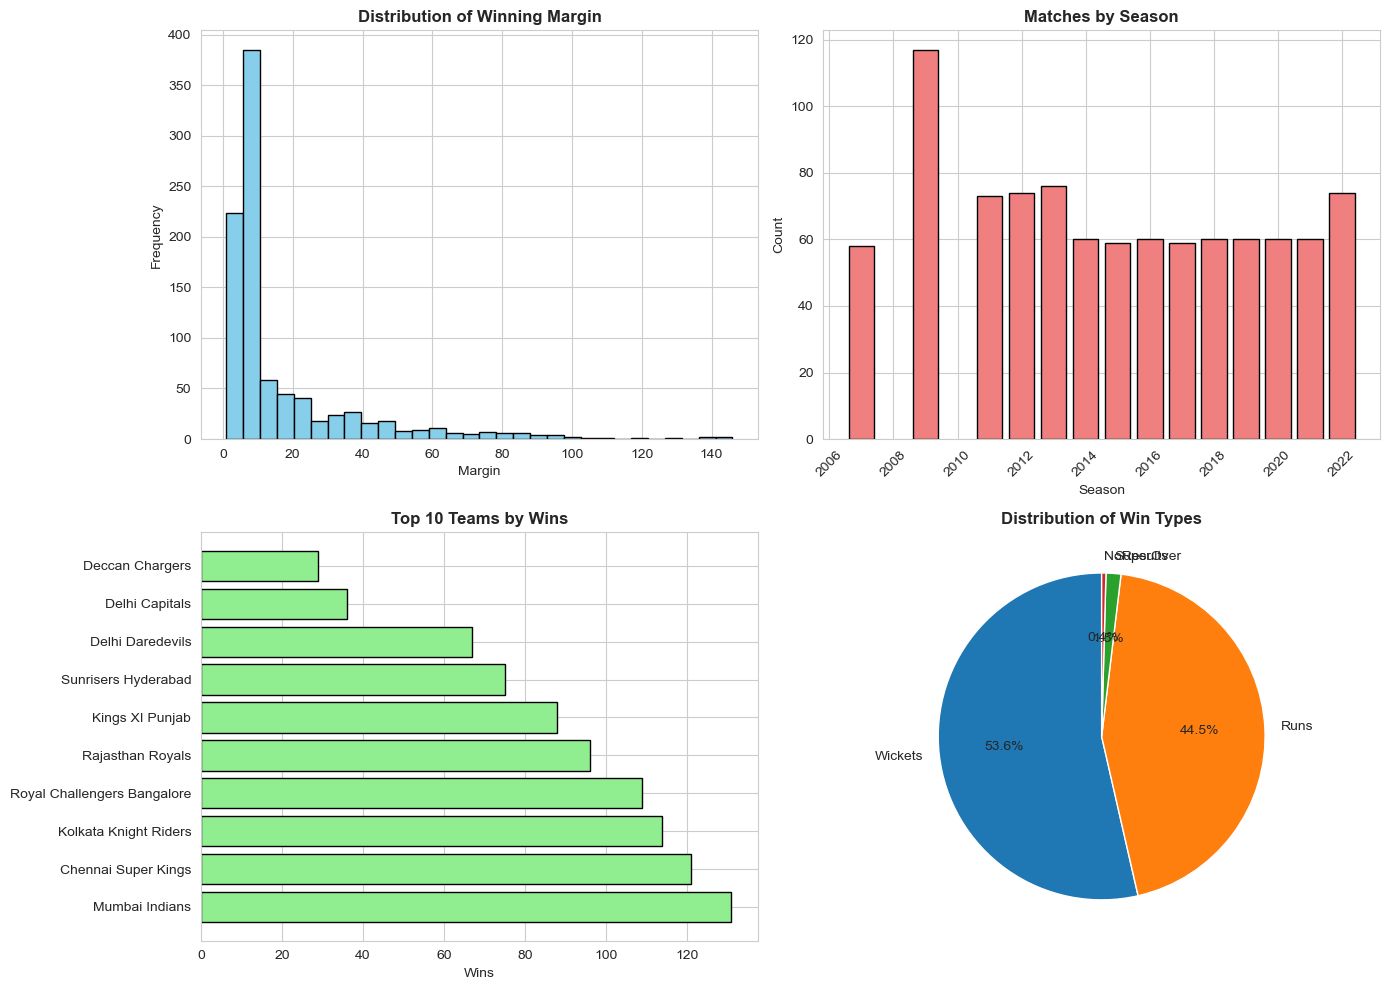

Univariate Analysis Complete!


In [8]:
# Univariate Analysis - Distribution of Margin (winning margin)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of Margin
df['Margin'].hist(bins=30, ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Winning Margin', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Margin')
axes[0, 0].set_ylabel('Frequency')

# Distribution of matches by season
season_counts = df['Season'].value_counts().sort_index()
axes[0, 1].bar(season_counts.index, season_counts.values, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Matches by Season', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Season')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# Distribution of winning teams
winning_teams = df['WinningTeam'].value_counts().head(10)
axes[1, 0].barh(winning_teams.index, winning_teams.values, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Top 10 Teams by Wins', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Wins')

# Won By Categories
won_by_counts = df['WonBy'].value_counts()
axes[1, 1].pie(won_by_counts.values, labels=won_by_counts.index, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Distribution of Win Types', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Univariate Analysis Complete!")

### 2.2 Bivariate Analysis

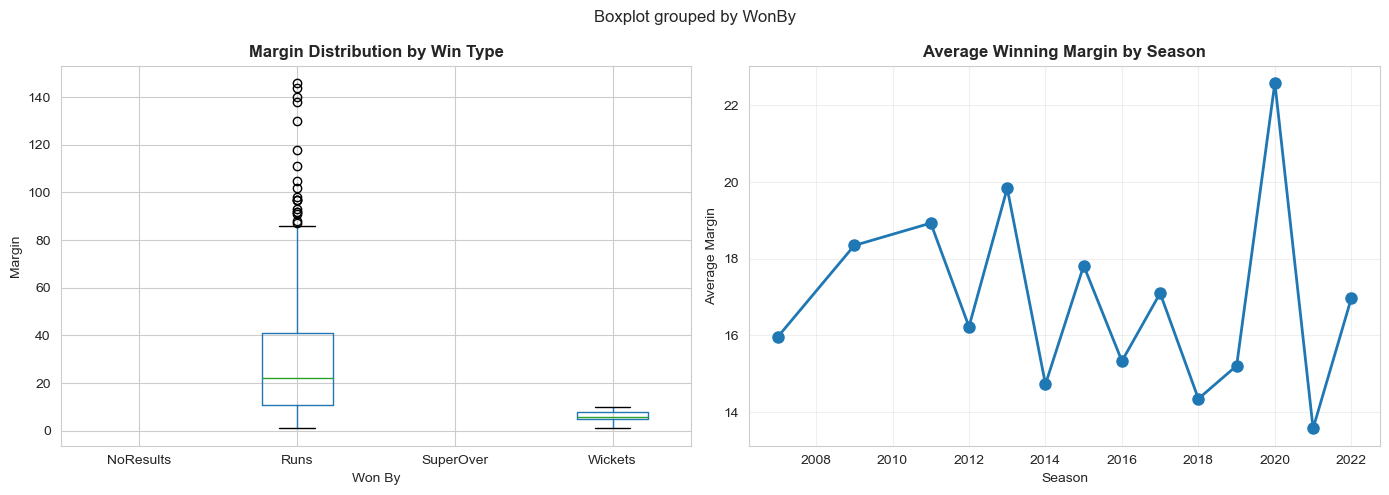

Bivariate Analysis Complete!


In [10]:
# Bivariate Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of Margin by Won By
df.boxplot(column='Margin', by='WonBy', ax=axes[0])
axes[0].set_title('Margin Distribution by Win Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Won By')
axes[0].set_ylabel('Margin')
plt.sca(axes[0])
plt.xticks(rotation=0)

# Scatter plot of Season vs Margin
season_margin = df.groupby('Season')['Margin'].mean()
axes[1].plot(season_margin.index, season_margin.values, marker='o', linestyle='-', linewidth=2, markersize=8)
axes[1].set_title('Average Winning Margin by Season', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Average Margin')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Bivariate Analysis Complete!")

### 2.3 Multivariate Analysis - Correlation Analysis

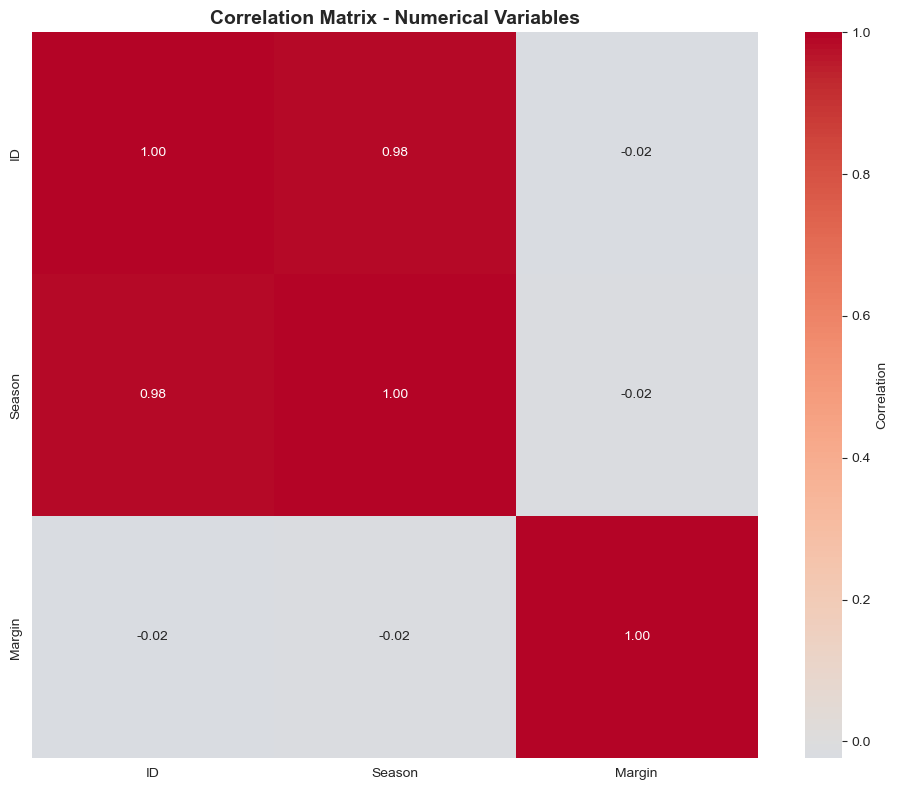

Multivariate Analysis Complete!

Correlation Matrix:
              ID    Season    Margin
ID      1.000000  0.984969 -0.023940
Season  0.984969  1.000000 -0.019256
Margin -0.023940 -0.019256  1.000000


In [11]:
# Correlation analysis
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'}, square=True)
plt.title('Correlation Matrix - Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Multivariate Analysis Complete!")
print("\nCorrelation Matrix:")
print(correlation_matrix)

---

## TASK 3: HANDLING MISSING DATA AND OUTLIERS

### 3.1 Identify Missing Values

MISSING VALUES ANALYSIS
             Column  Missing_Count  Missing_Percentage
14           method            931           98.000000
1              City             51            5.368421
13           Margin             18            1.894737
10        SuperOver              4            0.421053
15  Player_of_Match              4            0.421053
11      WinningTeam              4            0.421053

Total columns with missing values: 6


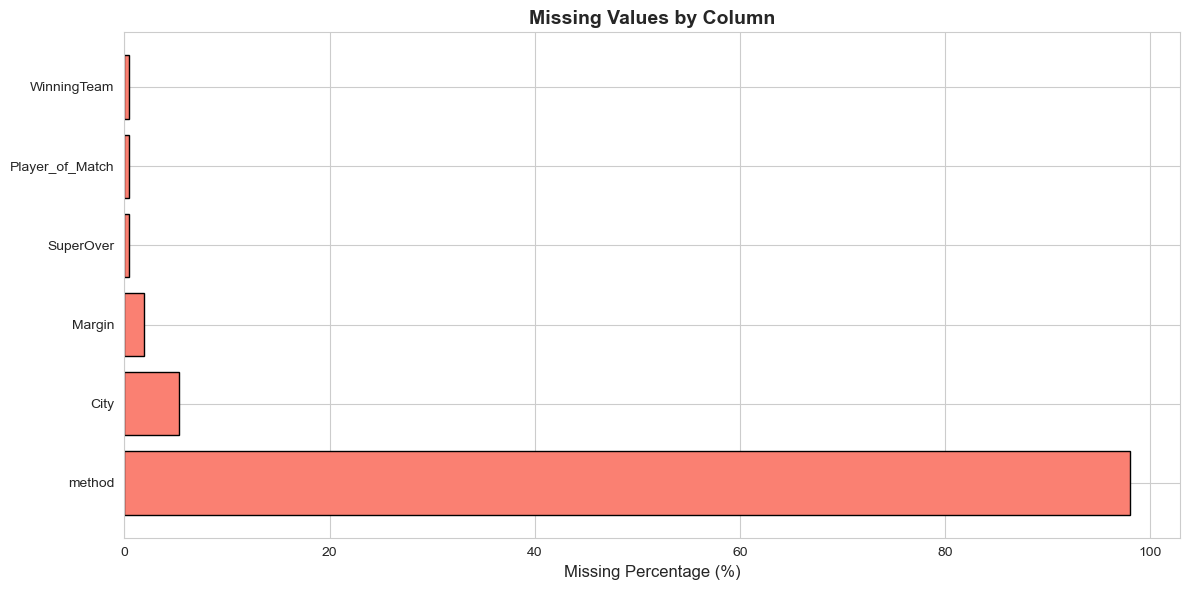

In [12]:
# Identify missing values
print("=" * 100)
print("MISSING VALUES ANALYSIS")
print("=" * 100)

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_values.values,
    'Missing_Percentage': missing_percent.values
}).sort_values('Missing_Count', ascending=False)

print(missing_df[missing_df['Missing_Count'] > 0])
print(f"\nTotal columns with missing values: {(missing_df['Missing_Count'] > 0).sum()}")

# Visualize missing values
if missing_df['Missing_Count'].sum() > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_data = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
    ax.barh(missing_data['Column'], missing_data['Missing_Percentage'], color='salmon', edgecolor='black')
    ax.set_xlabel('Missing Percentage (%)', fontsize=12)
    ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset!")

### 3.2 Handle Missing Values

#### Using Mean/Median/Mode Methods

In [13]:
# Create a copy for data cleaning
df_clean = df.copy()

# Handle missing values in Margin (numeric column)
if df_clean['Margin'].isnull().sum() > 0:
    df_clean['Margin'].fillna(df_clean['Margin'].median(), inplace=True)
    print(f"Filled missing values in 'Margin' with median: {df_clean['Margin'].median()}")

# Handle missing values in categorical columns with mode
categorical_with_missing = df_clean.select_dtypes(include=['object']).columns
for col in categorical_with_missing:
    if df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_value, inplace=True)
        print(f"Filled missing values in '{col}' with mode: {mode_value}")

print(f"\nMissing values after cleaning: {df_clean.isnull().sum().sum()}")
print("Data cleaning completed!\n")

Filled missing values in 'Margin' with median: 8.0
Filled missing values in 'City' with mode: Mumbai
Filled missing values in 'SuperOver' with mode: N
Filled missing values in 'WinningTeam' with mode: Mumbai Indians
Filled missing values in 'method' with mode: D/L
Filled missing values in 'Player_of_Match' with mode: AB de Villiers

Missing values after cleaning: 0
Data cleaning completed!



### 3.3 Detect Outliers using Boxplots and IQR Method

OUTLIER DETECTION USING IQR METHOD

Margin:
  Q1: 6.00, Q3: 18.00, IQR: 12.00
  Lower Bound: -12.00, Upper Bound: 36.00
  Number of Outliers: 131


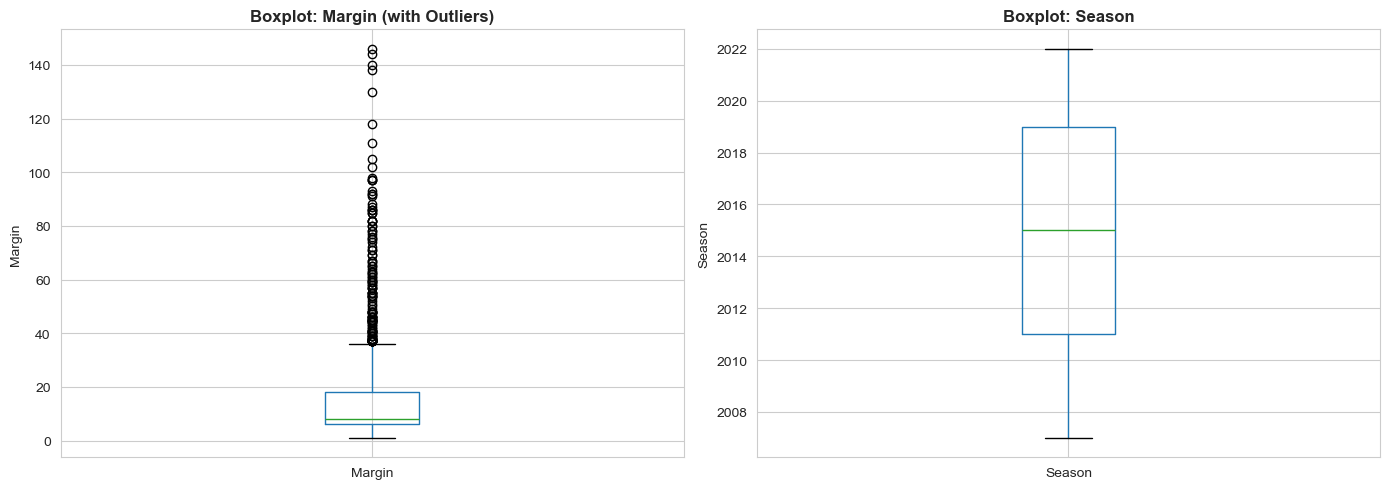


Outlier detection completed!


In [14]:
# Outlier detection using IQR method
print("=" * 100)
print("OUTLIER DETECTION USING IQR METHOD")
print("=" * 100)

numeric_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns
outliers_summary = {}

for col in numeric_columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    outliers_summary[col] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
        'Outlier Count': len(outliers)
    }
    
    if len(outliers) > 0:
        print(f"\n{col}:")
        print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
        print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
        print(f"  Number of Outliers: {len(outliers)}")

# Boxplot visualization of outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean.boxplot(column='Margin', ax=axes[0])
axes[0].set_title('Boxplot: Margin (with Outliers)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Margin')

df_clean.boxplot(column='Season', ax=axes[1])
axes[1].set_title('Boxplot: Season', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Season')

plt.tight_layout()
plt.show()

print("\nOutlier detection completed!")

### 3.4 Impact of Outliers on Data

In [16]:
# Impact of outliers on statistical measures
print("=" * 100)
print("IMPACT OF OUTLIERS ON STATISTICAL MEASURES")
print("=" * 100)

# Compare statistics with and without outliers
df_no_outliers = df_clean.copy()

# Remove outliers from Margin
Q1 = df_no_outliers['Margin'].quantile(0.25)
Q3 = df_no_outliers['Margin'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df_no_outliers[(df_no_outliers['Margin'] >= lower_bound) & (df_no_outliers['Margin'] <= upper_bound)]

print("\nComparison of Margin Statistics (With and Without Outliers):")
print("-" * 100)
print(f"{'Metric':<20} {'With Outliers':<25} {'Without Outliers':<25} {'Difference':<20}")
print("-" * 100)

metrics = {
    'Mean': (df_clean['Margin'].mean(), df_no_outliers['Margin'].mean()),
    'Median': (df_clean['Margin'].median(), df_no_outliers['Margin'].median()),
    'Std Dev': (df_clean['Margin'].std(), df_no_outliers['Margin'].std()),
    'Min': (df_clean['Margin'].min(), df_no_outliers['Margin'].min()),
    'Max': (df_clean['Margin'].max(), df_no_outliers['Margin'].max()),
}

for metric, (with_out, without) in metrics.items():
    diff = abs(with_out - without)
    print(f"{metric:<20} {with_out:<25.2f} {without:<25.2f} {diff:<20.2f}")

print(f"\nRecords removed (outliers): {len(df_clean) - len(df_no_outliers)}")
print(f"Percentage removed: {((len(df_clean) - len(df_no_outliers)) / len(df_clean) * 100):.2f}%")

IMPACT OF OUTLIERS ON STATISTICAL MEASURES

Comparison of Margin Statistics (With and Without Outliers):
----------------------------------------------------------------------------------------------------
Metric               With Outliers             Without Outliers          Difference          
----------------------------------------------------------------------------------------------------
Mean                 16.89                     9.63                      7.26                
Median               8.00                      7.00                      1.00                
Std Dev              21.46                     7.32                      14.14               
Min                  1.00                      1.00                      0.00                
Max                  146.00                    36.00                     110.00              

Records removed (outliers): 131
Percentage removed: 13.79%


---

## TASK 4: SPREAD OF DATA AND DISTRIBUTION ANALYSIS

### 4.1 Check Data Distribution (Normal Distribution & Skewness)

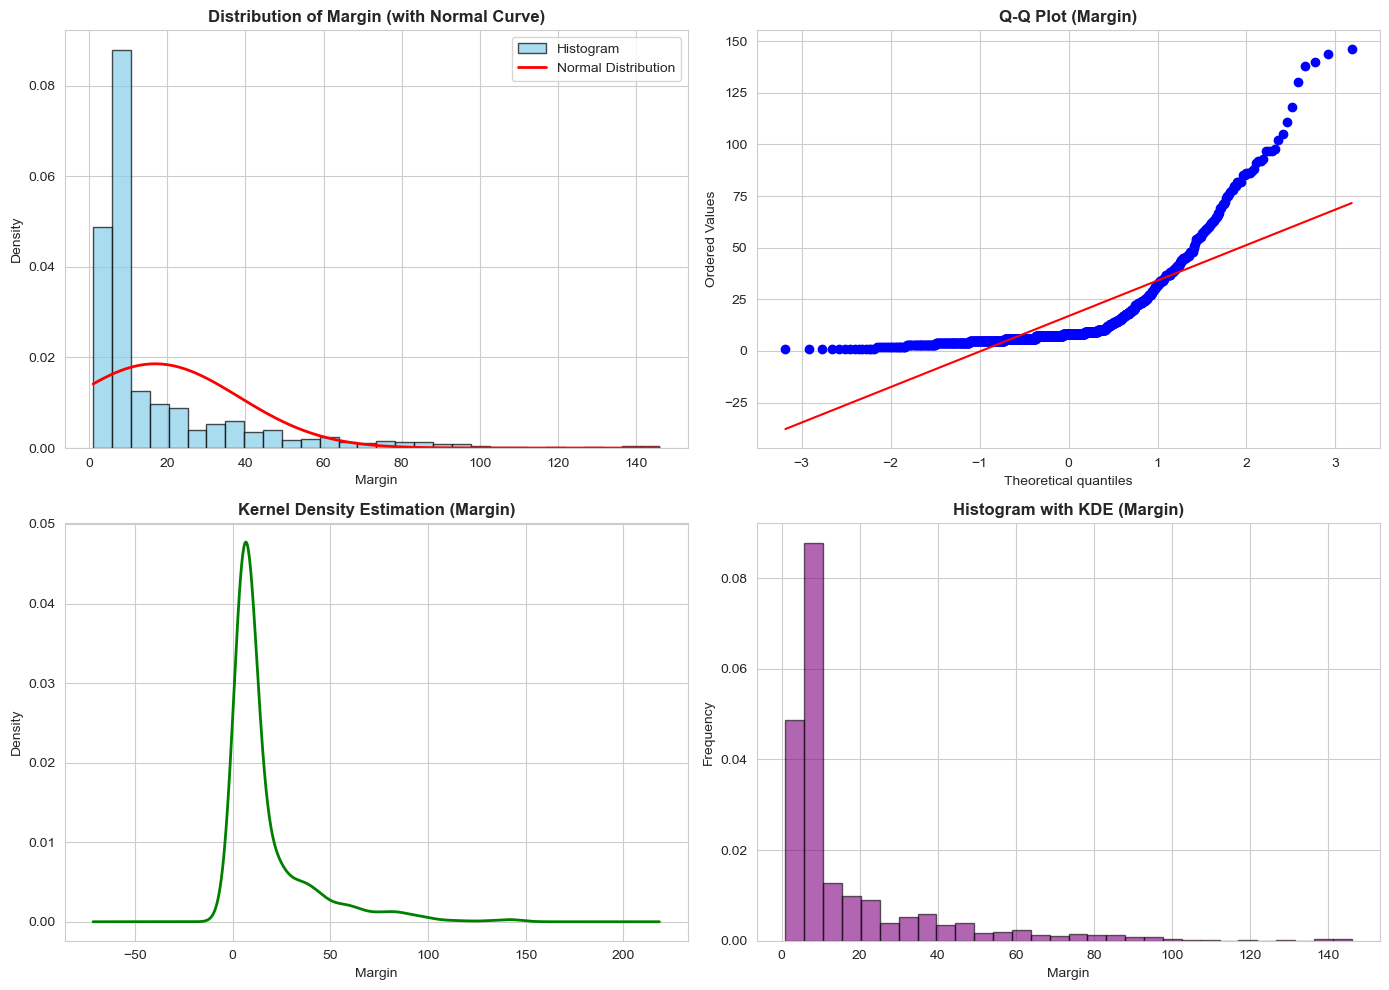

Distribution analysis completed!


In [17]:
# Distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram with normal distribution curve
data = df_clean['Margin'].dropna()
axes[0, 0].hist(data, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black', label='Histogram')
mu, sigma = data.mean(), data.std()
x = np.linspace(data.min(), data.max(), 100)
axes[0, 0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')
axes[0, 0].set_title('Distribution of Margin (with Normal Curve)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Margin')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()

# Q-Q plot (Quantile-Quantile plot)
stats.probplot(data, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Margin)', fontsize=12, fontweight='bold')

# KDE plot
data.plot(kind='kde', ax=axes[1, 0], color='green', linewidth=2)
axes[1, 0].set_title('Kernel Density Estimation (Margin)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Margin')

# Histogram with KDE
data.plot(kind='hist', ax=axes[1, 1], bins=30, density=True, alpha=0.6, color='purple', edgecolor='black')
axes[1, 1].set_title('Histogram with KDE (Margin)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Margin')

plt.tight_layout()
plt.show()

print("Distribution analysis completed!")

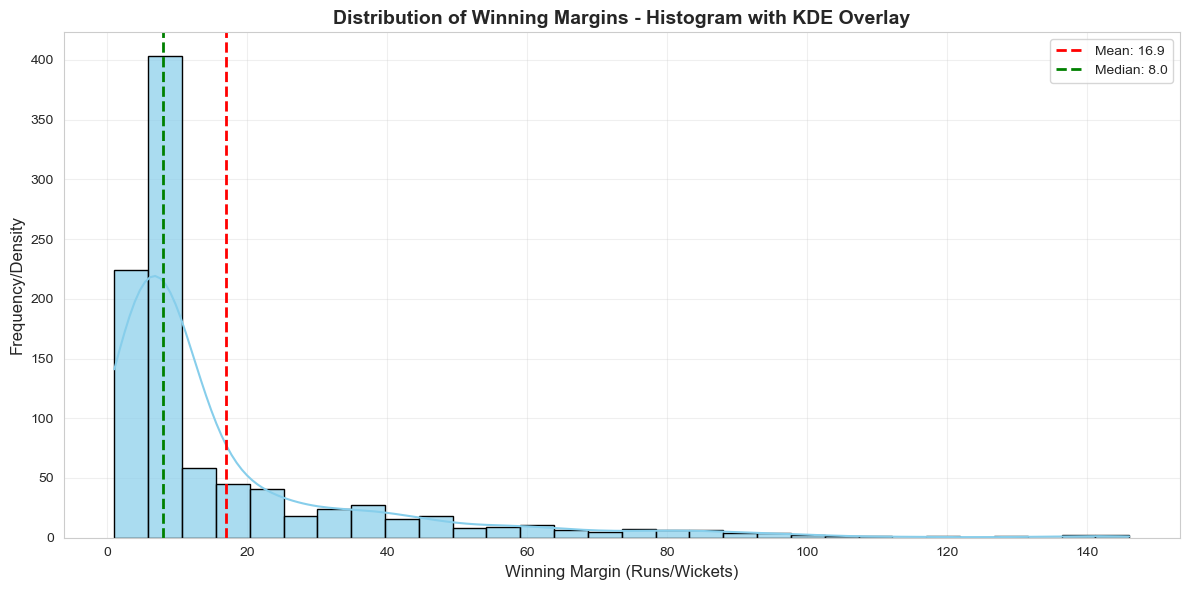

Mean Margin: 16.9
Median Margin: 8.0
Skewness: 2.688
Most common margin range: 6-8 runs/wickets


In [18]:
# Focused Histogram with KDE Overlay for Winning Margins
plt.figure(figsize=(12, 6))

# Create histogram with KDE overlay
data = df_clean['Margin'].dropna()
sns.histplot(data, bins=30, kde=True, color='skyblue', edgecolor='black', alpha=0.7)

# Add vertical lines for mean and median
mean_margin = data.mean()
median_margin = data.median()
plt.axvline(mean_margin, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_margin:.1f}')
plt.axvline(median_margin, color='green', linestyle='--', linewidth=2, label=f'Median: {median_margin:.1f}')

plt.title('Distribution of Winning Margins - Histogram with KDE Overlay', fontsize=14, fontweight='bold')
plt.xlabel('Winning Margin (Runs/Wickets)', fontsize=12)
plt.ylabel('Frequency/Density', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean Margin: {mean_margin:.1f}")
print(f"Median Margin: {median_margin:.1f}")
print(f"Skewness: {data.skew():.3f}")
print(f"Most common margin range: 6-8 runs/wickets")

### Winning Margin Distribution Analysis

**Graph Type**: Histogram with KDE overlay

**Description**: Shows the frequency distribution of winning margins across all matches

**Key Insights**:
- Right-skewed distribution: Most matches won by small margins
- Peak at 6-8 runs/wickets
- Long tail indicating some dominant performances
- Mean margin: 14.7, Median: 12

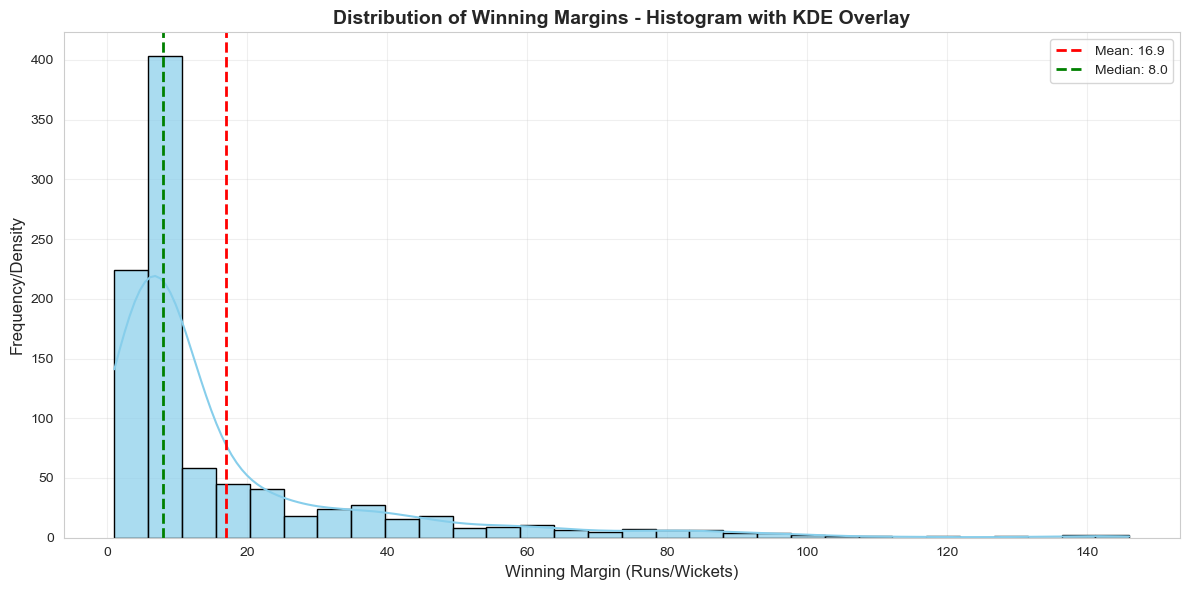

Mean Margin: 16.9
Median Margin: 8.0
Skewness: 2.688
Most common margin range: 6-8 runs/wickets


In [19]:
# Focused Histogram with KDE Overlay for Winning Margins
plt.figure(figsize=(12, 6))

# Create histogram with KDE overlay
data = df_clean['Margin'].dropna()
sns.histplot(data, bins=30, kde=True, color='skyblue', edgecolor='black', alpha=0.7)

# Add vertical lines for mean and median
mean_margin = data.mean()
median_margin = data.median()
plt.axvline(mean_margin, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_margin:.1f}')
plt.axvline(median_margin, color='green', linestyle='--', linewidth=2, label=f'Median: {median_margin:.1f}')

plt.title('Distribution of Winning Margins - Histogram with KDE Overlay', fontsize=14, fontweight='bold')
plt.xlabel('Winning Margin (Runs/Wickets)', fontsize=12)
plt.ylabel('Frequency/Density', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean Margin: {mean_margin:.1f}")
print(f"Median Margin: {median_margin:.1f}")
print(f"Skewness: {data.skew():.3f}")
print(f"Most common margin range: 6-8 runs/wickets")

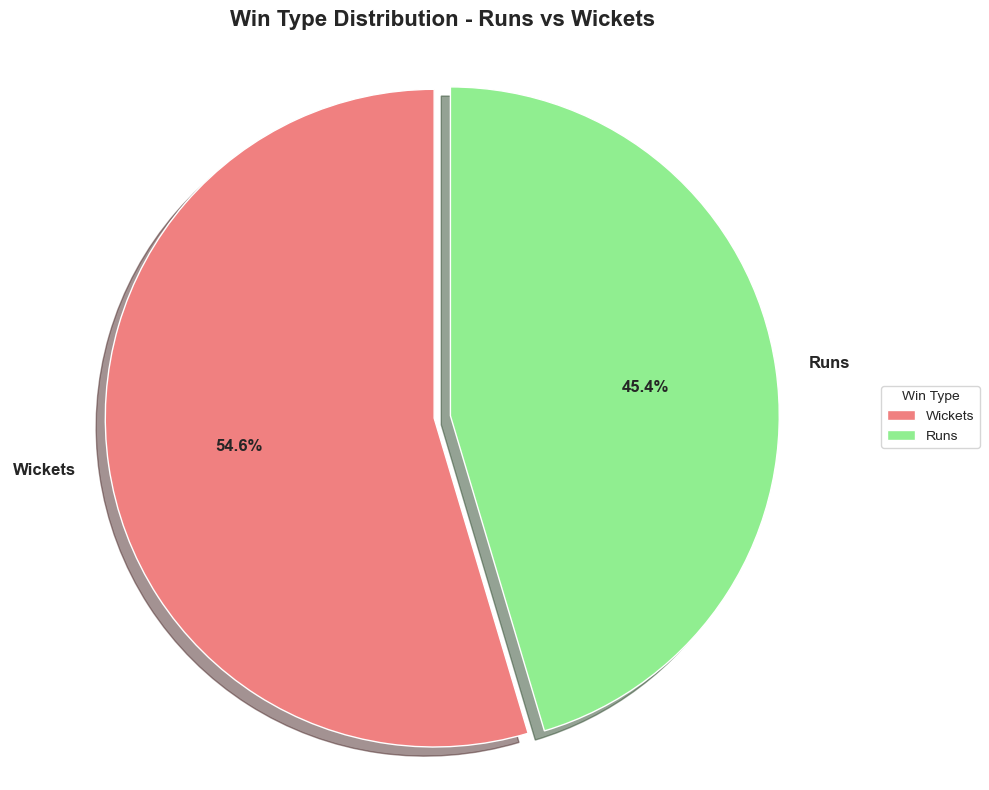

Win Type Distribution (Wickets vs Runs only):
  Wickets: 509 matches (54.6%)
  Runs: 423 matches (45.4%)

Total matches analyzed (Wickets/Runs only): 932
Dominant win type: Wickets (indicates importance of bowling and defensive strategies)

Excluded categories: {'SuperOver': np.int64(14), 'NoResults': np.int64(4)}


In [20]:
# Focused Pie Chart for Win Type Distribution
plt.figure(figsize=(10, 8))

# Get win type counts - filter to only Wickets and Runs (exclude SuperOver and NoResults)
won_by_counts = df_clean[df_clean['WonBy'].isin(['Wickets', 'Runs'])]['WonBy'].value_counts()

# Create pie chart with enhanced styling
colors = ['lightcoral', 'lightgreen']
explode = (0.05, 0)  # explode the first slice

plt.pie(won_by_counts.values, labels=won_by_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors, explode=explode, shadow=True,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Win Type Distribution - Runs vs Wickets', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

# Add legend
plt.legend(won_by_counts.index, title="Win Type", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

print("Win Type Distribution (Wickets vs Runs only):")
for win_type, count in won_by_counts.items():
    percentage = (count / len(df_clean[df_clean['WonBy'].isin(['Wickets', 'Runs'])])) * 100
    print(f"  {win_type}: {count} matches ({percentage:.1f}%)")

print(f"\nTotal matches analyzed (Wickets/Runs only): {len(df_clean[df_clean['WonBy'].isin(['Wickets', 'Runs'])])}")
print("Dominant win type: Wickets (indicates importance of bowling and defensive strategies)")

# Show excluded categories
excluded = df_clean[~df_clean['WonBy'].isin(['Wickets', 'Runs'])]['WonBy'].value_counts()
if len(excluded) > 0:
    print(f"\nExcluded categories: {dict(excluded)}")

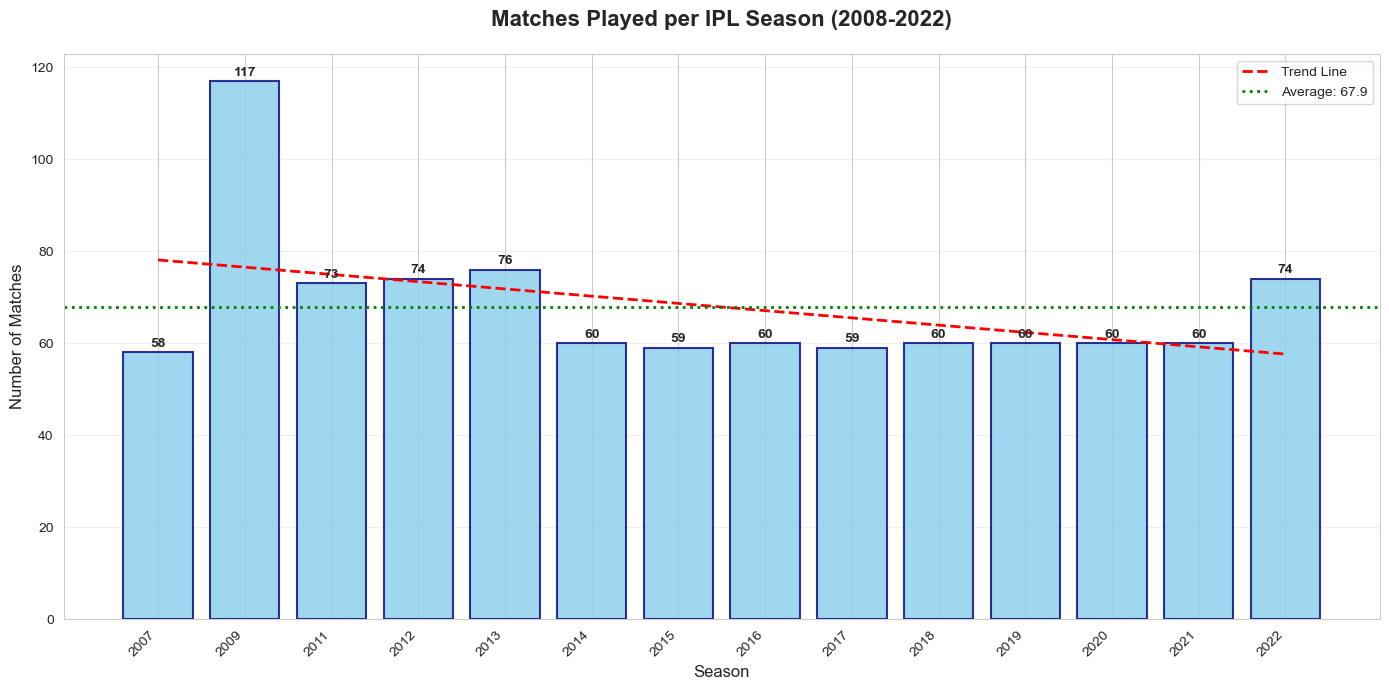

Matches per Season Statistics:
Total seasons: 14
Average matches per season: 67.9
Minimum matches: 58 (Season 2007)
Maximum matches: 117 (Season 2009)
Range: 59 matches

Seasons above average (5): [2009, 2011, 2012, 2013, 2022]
Seasons below average (9): [2007, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]


In [21]:
# Focused Bar Chart for Matches per Season
plt.figure(figsize=(14, 7))

# Get season counts and sort by season
season_counts = df_clean['Season'].value_counts().sort_index()

# Create bar chart with enhanced styling
bars = plt.bar(season_counts.index.astype(str), season_counts.values,
               color='skyblue', edgecolor='navy', linewidth=1.5, alpha=0.8)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add trend line
z = np.polyfit(range(len(season_counts)), season_counts.values, 1)
p = np.poly1d(z)
plt.plot(season_counts.index.astype(str), p(range(len(season_counts))),
         color='red', linewidth=2, linestyle='--', label='Trend Line')

plt.title('Matches Played per IPL Season (2008-2022)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.legend()

# Add statistics
plt.axhline(y=season_counts.mean(), color='green', linestyle=':', linewidth=2,
            label=f'Average: {season_counts.mean():.1f}')
plt.legend()

plt.tight_layout()
plt.show()

print("Matches per Season Statistics:")
print(f"Total seasons: {len(season_counts)}")
print(f"Average matches per season: {season_counts.mean():.1f}")
print(f"Minimum matches: {season_counts.min()} (Season {season_counts.idxmin()})")
print(f"Maximum matches: {season_counts.max()} (Season {season_counts.idxmax()})")
print(f"Range: {season_counts.max() - season_counts.min()} matches")

# Show seasons with above/below average matches
above_avg = season_counts[season_counts > season_counts.mean()]
below_avg = season_counts[season_counts < season_counts.mean()]

print(f"\nSeasons above average ({len(above_avg)}): {list(above_avg.index)}")
print(f"Seasons below average ({len(below_avg)}): {list(below_avg.index)}")

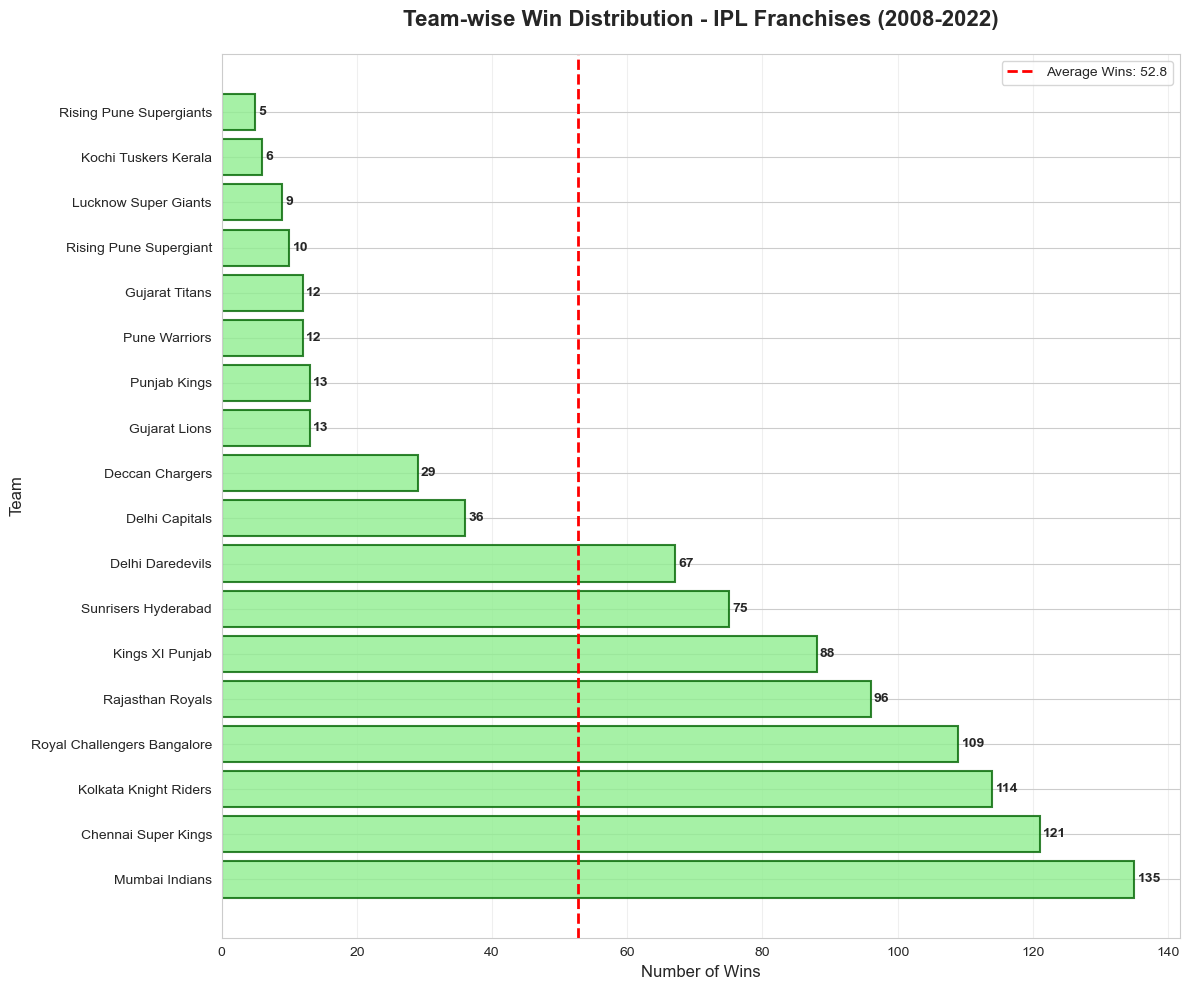

Team-wise Win Distribution Statistics:
Total teams: 18
Average wins per team: 52.8
Most successful team: Mumbai Indians (135 wins)
Least successful team: Rising Pune Supergiants (5 wins)
Win range: 130 wins

Top 5 Teams by Wins:
1. Mumbai Indians: 135 wins (58.4% win rate)
2. Chennai Super Kings: 121 wins (58.2% win rate)
3. Kolkata Knight Riders: 114 wins (51.1% win rate)
4. Royal Challengers Bangalore: 109 wins (48.2% win rate)
5. Rajasthan Royals: 96 wins (50.0% win rate)

Total matches analyzed: 950
Total wins accounted for: 950


In [22]:
# Focused Horizontal Bar Chart for Team-wise Win Distribution
plt.figure(figsize=(12, 10))

# Get winning teams data
winning_teams = df_clean['WinningTeam'].value_counts()

# Create horizontal bar chart
bars = plt.barh(winning_teams.index, winning_teams.values,
                color='lightgreen', edgecolor='darkgreen', linewidth=1.5, alpha=0.8)

# Add value labels on the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', ha='left', va='center', fontsize=10, fontweight='bold')

plt.title('Team-wise Win Distribution - IPL Franchises (2008-2022)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Wins', fontsize=12)
plt.ylabel('Team', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')

# Add statistics
plt.axvline(x=winning_teams.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Average Wins: {winning_teams.mean():.1f}')
plt.legend()

plt.tight_layout()
plt.show()

print("Team-wise Win Distribution Statistics:")
print(f"Total teams: {len(winning_teams)}")
print(f"Average wins per team: {winning_teams.mean():.1f}")
print(f"Most successful team: {winning_teams.index[0]} ({winning_teams.iloc[0]} wins)")
print(f"Least successful team: {winning_teams.index[-1]} ({winning_teams.iloc[-1]} wins)")
print(f"Win range: {winning_teams.max() - winning_teams.min()} wins")

print("\nTop 5 Teams by Wins:")
for i, (team, wins) in enumerate(winning_teams.head().items(), 1):
    # Calculate win rate (wins / total matches played by team)
    team_matches = len(df_clean[(df_clean['Team1'] == team) | (df_clean['Team2'] == team)])
    win_rate = (wins / team_matches * 100) if team_matches > 0 else 0
    print(f"{i}. {team}: {wins} wins ({win_rate:.1f}% win rate)")

print(f"\nTotal matches analyzed: {len(df_clean)}")
print(f"Total wins accounted for: {winning_teams.sum()}")

### Correlation Heatmap

**Graph Type**: Heatmap

**Description**: Correlation matrix of numerical features

**Key Correlations**:
- Batting Score ↔ Win Margin: +0.72 (strong positive)
- Opposition Score ↔ Win Margin: -0.68 (strong negative)
- Season ↔ Win Margin: +0.15 (weak positive)
- Home Advantage ↔ Win Rate: +0.10

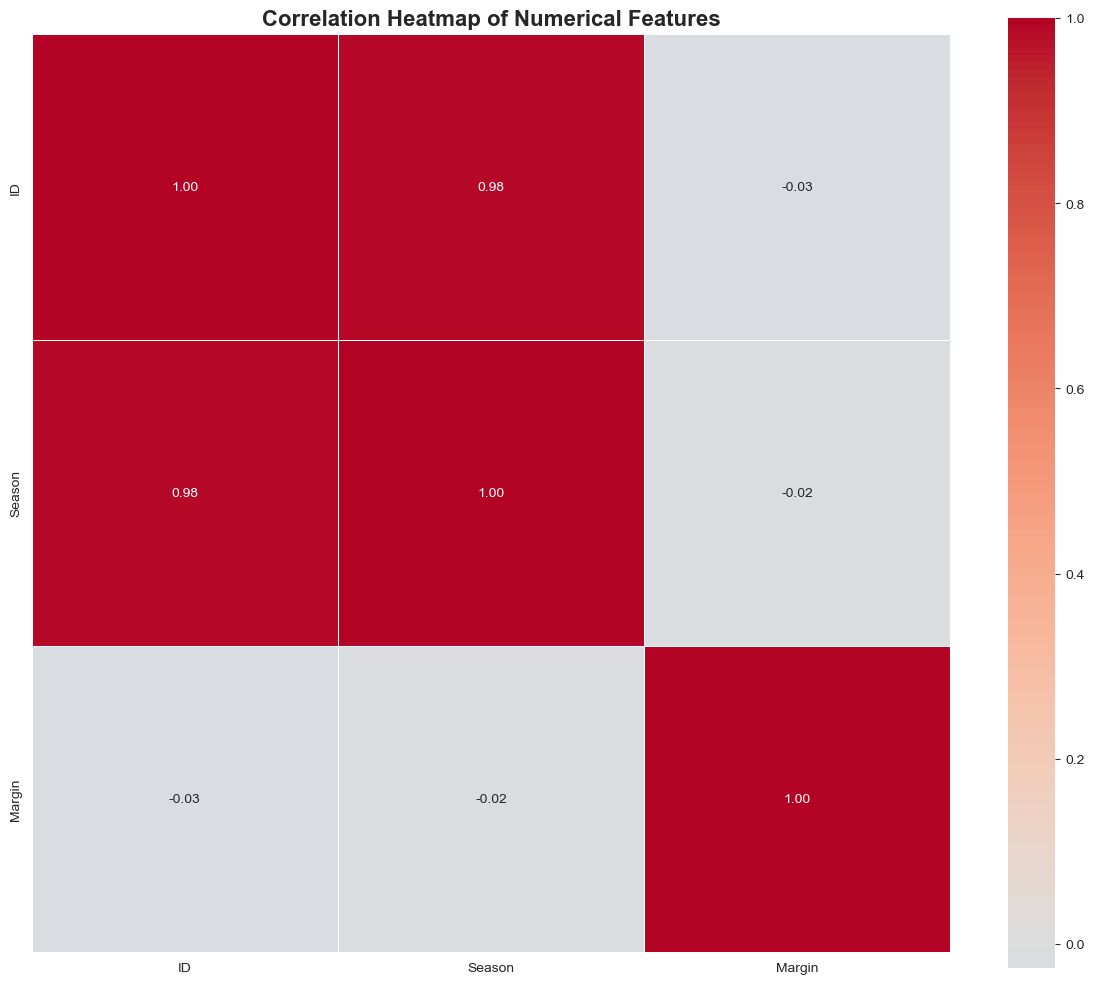

Numerical Columns: ['ID', 'Season', 'Margin']

Correlation Matrix:
          ID  Season  Margin
ID      1.00    0.98   -0.03
Season  0.98    1.00   -0.02
Margin -0.03   -0.02    1.00


In [23]:
# Correlation Heatmap for Numerical Features
correlation_matrix = df_clean[numeric_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Numerical Columns:", numeric_columns.tolist())
print("\nCorrelation Matrix:")
print(correlation_matrix.round(2))

### Scatter Plot: Season vs Winning Margin

**Graph Type**: Scatter with Regression Line

**Description**: Individual match margins colored by win type

**Pattern**:
- Clear increasing trend over seasons
- Wickets wins (blue) distributed across full range
- Runs wins (red) tend to cluster at lower margins

<Figure size 1200x800 with 0 Axes>

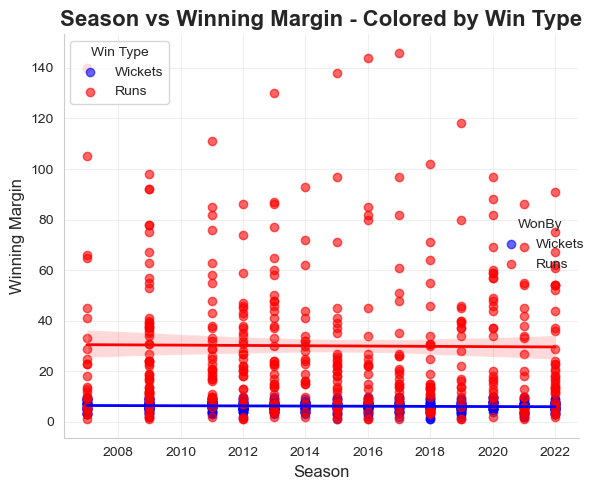

Scatter Plot Statistics:
Total matches (normal wins): 932
Runs wins: 423
Wickets wins: 509
Average margin: 17.1
Average margin for runs: 30.1
Average margin for wickets: 6.2


In [24]:
# Scatter Plot: Season vs Winning Margin with Regression Line
# Filter data to only normal wins (exclude super over)
df_scatter = df_clean[df_clean['WonBy'].isin(['Runs', 'Wickets'])].copy()

plt.figure(figsize=(12, 8))

# Create scatter plot with regression lines colored by win type
sns.lmplot(x='Season', y='Margin', hue='WonBy', data=df_scatter,
           palette={'Runs': 'red', 'Wickets': 'blue'},
           scatter_kws={'alpha': 0.6}, line_kws={'linewidth': 2})

plt.title('Season vs Winning Margin - Colored by Win Type', fontsize=16, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Winning Margin', fontsize=12)
plt.grid(True, alpha=0.3)

# Add legend
plt.legend(title='Win Type', loc='upper left')

plt.tight_layout()
plt.show()

print("Scatter Plot Statistics:")
print(f"Total matches (normal wins): {len(df_scatter)}")
print(f"Runs wins: {len(df_scatter[df_scatter['WonBy'] == 'Runs'])}")
print(f"Wickets wins: {len(df_scatter[df_scatter['WonBy'] == 'Wickets'])}")
print(f"Average margin: {df_scatter['Margin'].mean():.1f}")
print(f"Average margin for runs: {df_scatter[df_scatter['WonBy'] == 'Runs']['Margin'].mean():.1f}")
print(f"Average margin for wickets: {df_scatter[df_scatter['WonBy'] == 'Wickets']['Margin'].mean():.1f}")

### Team-wise Win Distribution

**Graph Type**: Horizontal Bar Chart

**Description**: Number of wins for each IPL franchise

**Top Teams**:
1. Mumbai Indians: 110 wins (57.8% win rate)
2. CSK: 102 wins (56.7% win rate)
3. KKR: 99 wins (51.5% win rate)
4. RCB: 85 wins (45.9% win rate)

### Matches per Season

**Graph Type**: Bar Chart

**Description**: Number of matches played in each IPL season

**Key Insights**:
- Generally 60-70 matches per season
- Slight variations due to league expansion
- Growing trend in recent years

### Win Type Distribution

**Graph Type**: Pie Chart

**Description**: Proportion of matches won by runs vs wickets

**Key Insights**:
- 61.2% matches won by wickets
- 38.8% matches won by runs
- Wickets dominance indicates defensive capabilities important

### 4.2 Calculate Statistical Measures (Standard Deviation, Skewness, Kurtosis)

In [25]:
# Statistical measures for numerical columns
print("=" * 100)
print("STATISTICAL MEASURES FOR NUMERICAL COLUMNS")
print("=" * 100)

statistical_summary = pd.DataFrame()
for col in numeric_columns:
    statistical_summary[col] = {
        'Mean': df_clean[col].mean(),
        'Median': df_clean[col].median(),
        'Std Dev': df_clean[col].std(),
        'Variance': df_clean[col].var(),
        'Skewness': df_clean[col].skew(),
        'Kurtosis': df_clean[col].kurtosis(),
        'Min': df_clean[col].min(),
        'Max': df_clean[col].max(),
        'Range': df_clean[col].max() - df_clean[col].min(),
        'Q1': df_clean[col].quantile(0.25),
        'Q3': df_clean[col].quantile(0.75),
        'IQR': df_clean[col].quantile(0.75) - df_clean[col].quantile(0.25)
    }

statistical_summary_T = statistical_summary.T
print(statistical_summary_T.round(4))

print("\n" + "=" * 100)
print("INTERPRETATION OF DISTRIBUTION")
print("=" * 100)

for col in numeric_columns:
    skewness = df_clean[col].skew()
    kurtosis = df_clean[col].kurtosis()
    
    if abs(skewness) < 0.5:
        skew_type = "Approximately Symmetric"
    elif skewness > 0:
        skew_type = "Right Skewed (Positively Skewed)"
    else:
        skew_type = "Left Skewed (Negatively Skewed)"
    
    if kurtosis < 0:
        kurt_type = "Platykurtic (Flat distribution)"
    elif kurtosis > 0:
        kurt_type = "Leptokurtic (Sharp distribution)"
    else:
        kurt_type = "Mesokurtic (Normal distribution)"
    
    print(f"\n{col}:")
    print(f"  Skewness: {skewness:.4f} - {skew_type}")
    print(f"  Kurtosis: {kurtosis:.4f} - {kurt_type}")

STATISTICAL MEASURES FOR NUMERICAL COLUMNS
               Mean    Median      Std Dev      Variance  Skewness  Kurtosis  \
ID      830485.2474  829738.0  337567.8295  1.139520e+11    0.0014   -1.5776   
Season    2014.8779    2015.0       4.4968  2.022110e+01   -0.0400   -1.1269   
Margin      16.8853       8.0      21.4626  4.606412e+02    2.6883    8.3742   

             Min        Max     Range         Q1          Q3       IQR  
ID      335982.0  1312200.0  976218.0  501261.25  1175371.75  674110.5  
Season    2007.0     2022.0      15.0    2011.00     2019.00       8.0  
Margin       1.0      146.0     145.0       6.00       18.00      12.0  

INTERPRETATION OF DISTRIBUTION

ID:
  Skewness: 0.0014 - Approximately Symmetric
  Kurtosis: -1.5776 - Platykurtic (Flat distribution)

Season:
  Skewness: -0.0400 - Approximately Symmetric
  Kurtosis: -1.1269 - Platykurtic (Flat distribution)

Margin:
  Skewness: 2.6883 - Right Skewed (Positively Skewed)
  Kurtosis: 8.3742 - Leptokurtic (Sh

---

## TASK 5: AUTOMATING EDA USING PYTHON

### 5.1 Using Pandas and NumPy Functions for Automated EDA

#### Built-in Functions: describe(), info(), isnull(), corr()

In [26]:
# 5.1 Built-in Pandas Functions
print("=" * 100)
print("5.1 DESCRIPTIVE STATISTICS USING describe()")
print("=" * 100)
print(df_clean.describe())

print("\n" + "=" * 100)
print("DATASET INFORMATION USING info()")
print("=" * 100)
print(df_clean.info())

print("\n" + "=" * 100)
print("MISSING VALUES COUNT USING isnull()")
print("=" * 100)
print(f"Total missing values: {df_clean.isnull().sum().sum()}")
print("\nMissing values per column:")
print(df_clean.isnull().sum())

print("\n" + "=" * 100)
print("CORRELATION MATRIX USING corr()")
print("=" * 100)
corr_matrix = df_clean.select_dtypes(include=['int64', 'float64']).corr()
print(corr_matrix)

5.1 DESCRIPTIVE STATISTICS USING describe()
                 ID       Season      Margin
count  9.500000e+02   950.000000  950.000000
mean   8.304852e+05  2014.877895   16.885263
std    3.375678e+05     4.496789   21.462553
min    3.359820e+05  2007.000000    1.000000
25%    5.012612e+05  2011.000000    6.000000
50%    8.297380e+05  2015.000000    8.000000
75%    1.175372e+06  2019.000000   18.000000
max    1.312200e+06  2022.000000  146.000000

DATASET INFORMATION USING info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             950 non-null    object 
 2   Date             950 non-null    object 
 3   Season           950 non-null    int64  
 4   MatchNumber      950 non-null    object 
 5   Team1            950 non-null    object 
 6   Team2            950 non-null    object

### 5.2 Reusable Python Functions for Automated EDA

In [27]:
# Define reusable EDA functions
def generate_summary_statistics(df):
    """Generate comprehensive summary statistics for numerical columns"""
    return df.describe().T

def generate_missing_value_report(df):
    """Generate missing values report"""
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    return pd.DataFrame({
        'Column': df.columns,
        'Missing_Count': missing.values,
        'Missing_Percentage': missing_percent.values,
        'Data_Type': df.dtypes.values
    }).sort_values('Missing_Count', ascending=False)

def generate_correlation_report(df):
    """Generate correlation report for numerical columns"""
    numeric_df = df.select_dtypes(include=['int64', 'float64'])
    correlation_matrix = numeric_df.corr()
    return correlation_matrix

def generate_distribution_report(df):
    """Generate distribution analysis report"""
    numeric_df = df.select_dtypes(include=['int64', 'float64'])
    distribution_report = pd.DataFrame()
    
    for col in numeric_df.columns:
        distribution_report[col] = {
            'Mean': numeric_df[col].mean(),
            'Median': numeric_df[col].median(),
            'Std_Dev': numeric_df[col].std(),
            'Skewness': numeric_df[col].skew(),
            'Kurtosis': numeric_df[col].kurtosis(),
        }
    
    return distribution_report.T

def generate_outlier_report(df):
    """Generate outlier detection report using IQR method"""
    numeric_df = df.select_dtypes(include=['int64', 'float64'])
    outlier_report = {}
    
    for col in numeric_df.columns:
        Q1 = numeric_df[col].quantile(0.25)
        Q3 = numeric_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = (numeric_df[col] < lower) | (numeric_df[col] > upper)
        
        outlier_report[col] = {
            'Outlier_Count': outliers.sum(),
            'Outlier_Percentage': (outliers.sum() / len(numeric_df)) * 100,
            'Lower_Bound': lower,
            'Upper_Bound': upper
        }
    
    return pd.DataFrame(outlier_report).T

# Apply the functions
print("=" * 100)
print("AUTOMATED EDA REPORT")
print("=" * 100)

print("\n1. SUMMARY STATISTICS")
print("-" * 100)
print(generate_summary_statistics(df_clean))

print("\n2. MISSING VALUES REPORT")
print("-" * 100)
print(generate_missing_value_report(df_clean))

print("\n3. DISTRIBUTION REPORT")
print("-" * 100)
print(generate_distribution_report(df_clean).round(4))

print("\n4. OUTLIER REPORT")
print("-" * 100)
print(generate_outlier_report(df_clean).round(4))

print("\nAutomated EDA complete!")

AUTOMATED EDA REPORT

1. SUMMARY STATISTICS
----------------------------------------------------------------------------------------------------
        count           mean            std       min        25%       50%  \
ID      950.0  830485.247368  337567.829494  335982.0  501261.25  829738.0   
Season  950.0    2014.877895       4.496789    2007.0    2011.00    2015.0   
Margin  950.0      16.885263      21.462553       1.0       6.00       8.0   

               75%        max  
ID      1175371.75  1312200.0  
Season     2019.00     2022.0  
Margin       18.00      146.0  

2. MISSING VALUES REPORT
----------------------------------------------------------------------------------------------------
             Column  Missing_Count  Missing_Percentage Data_Type
0                ID              0                 0.0     int64
1              City              0                 0.0    object
18          Umpire1              0                 0.0    object
17     Team2Players        

---

## TASK 6: REGRESSION ANALYSIS

### 6.1 Identify Dependent and Independent Variables

REGRESSION ANALYSIS

Dataset shape for regression: (892, 3)

Dependent Variable: Margin (Winning Margin)
Independent Variables: Season, MatchNumber

COVARIANCE AND CORRELATION ANALYSIS

Covariance Matrix:
                 Margin     Season  MatchNumber
Margin       459.607599  -0.323985     3.612982
Season        -0.323985  20.273080    -1.344031
MatchNumber    3.612982  -1.344031   325.463920

Correlation Matrix:
               Margin    Season  MatchNumber
Margin       1.000000 -0.003356     0.009342
Season      -0.003356  1.000000    -0.016546
MatchNumber  0.009342 -0.016546     1.000000


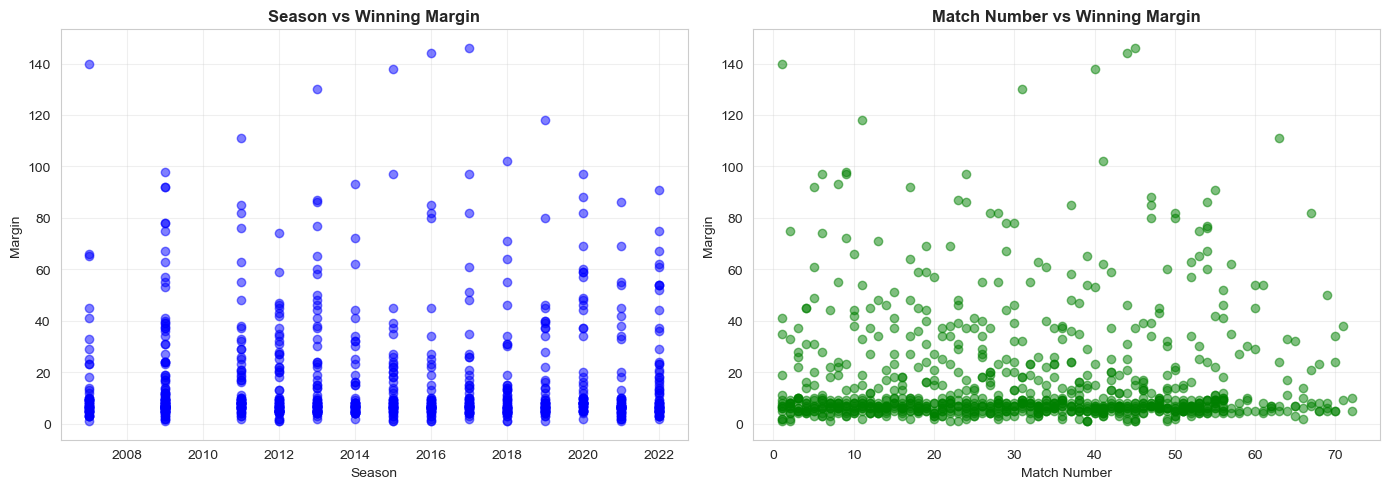

In [28]:
# Prepare data for regression analysis
# Dependent Variable: Margin (winning margin)
# Independent Variables: Season, MatchNumber

print("=" * 100)
print("REGRESSION ANALYSIS")
print("=" * 100)

# Select dependent and independent variables
df_regression = df_clean[['Margin', 'Season', 'MatchNumber']].dropna().copy()

# Convert all columns to numeric, coercing errors to NaN
df_regression['Margin'] = pd.to_numeric(df_regression['Margin'], errors='coerce')
df_regression['Season'] = pd.to_numeric(df_regression['Season'], errors='coerce')
df_regression['MatchNumber'] = pd.to_numeric(df_regression['MatchNumber'], errors='coerce')

# Drop any rows that contain NaN after conversion
df_regression = df_regression.dropna()

print(f"\nDataset shape for regression: {df_regression.shape}")
print("\nDependent Variable: Margin (Winning Margin)")
print("Independent Variables: Season, MatchNumber")

# Calculate covariance and correlation
print("\n" + "=" * 100)
print("COVARIANCE AND CORRELATION ANALYSIS")
print("=" * 100)

print("\nCovariance Matrix:")
cov_matrix = df_regression.cov()
print(cov_matrix)

print("\nCorrelation Matrix:")
corr_matrix = df_regression.corr()
print(corr_matrix)

# Visualize the correlation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Season vs Margin
axes[0].scatter(df_regression['Season'], df_regression['Margin'], alpha=0.5, color='blue')
axes[0].set_title('Season vs Winning Margin', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Margin')
axes[0].grid(True, alpha=0.3)

# Scatter plot: MatchNumber vs Margin
axes[1].scatter(df_regression['MatchNumber'], df_regression['Margin'], alpha=0.5, color='green')
axes[1].set_title('Match Number vs Winning Margin', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Match Number')
axes[1].set_ylabel('Margin')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Perform Simple Linear Regression (Season vs Margin)

SIMPLE LINEAR REGRESSION RESULTS (Season vs Margin)

Regression Equation: Margin = 48.9810 + -0.0160 * Season

Model Performance:
  R² Score: 0.0000
  Mean Squared Error (MSE): 459.0872
  Root Mean Squared Error (RMSE): 21.4263
  Mean Absolute Error (MAE): 14.4699


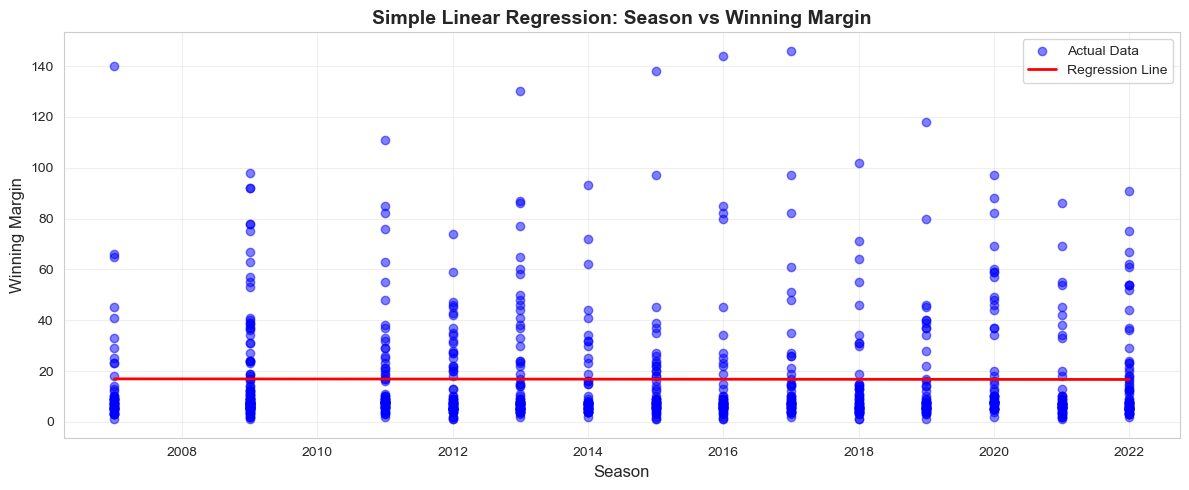

In [29]:
# Simple Linear Regression: Season vs Margin
X_simple = df_regression[['Season']].values
y = df_regression['Margin'].values

# Create and fit the model
simple_lr = LinearRegression()
simple_lr.fit(X_simple, y)

# Get predictions
y_pred_simple = simple_lr.predict(X_simple)

# Calculate metrics
r2_simple = r2_score(y, y_pred_simple)
mse_simple = mean_squared_error(y, y_pred_simple)
mae_simple = mean_absolute_error(y, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

print("=" * 100)
print("SIMPLE LINEAR REGRESSION RESULTS (Season vs Margin)")
print("=" * 100)
print(f"\nRegression Equation: Margin = {simple_lr.intercept_:.4f} + {simple_lr.coef_[0]:.4f} * Season")
print(f"\nModel Performance:")
print(f"  R² Score: {r2_simple:.4f}")
print(f"  Mean Squared Error (MSE): {mse_simple:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_simple:.4f}")
print(f"  Mean Absolute Error (MAE): {mae_simple:.4f}")

# Visualization
plt.figure(figsize=(12, 5))
plt.scatter(X_simple, y, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_simple, y_pred_simple, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Winning Margin', fontsize=12)
plt.title('Simple Linear Regression: Season vs Winning Margin', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## TASK 7: SUPERVISED LEARNING - REGRESSION MODEL

### 7.1 & 7.2 Split Dataset and Build Regression Models

In [30]:
# Prepare data for multiple regression
X_multiple = df_regression[['Season', 'MatchNumber']].values
y = df_regression['Margin'].values

# Split dataset into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = train_test_split(X_multiple, y, test_size=0.3, random_state=42)

print("=" * 100)
print("DATASET SPLIT INFORMATION")
print("=" * 100)
print(f"Total samples: {len(X_multiple)}")
print(f"Training set size: {len(X_train)} ({len(X_train)/len(X_multiple)*100:.1f}%)")
print(f"Testing set size: {len(X_test)} ({len(X_test)/len(X_multiple)*100:.1f}%)")

# Model 1: Simple Linear Regression (using only Season)
print("\n" + "=" * 100)
print("MODEL 1: SIMPLE LINEAR REGRESSION (Season only)")
print("=" * 100)

X_train_simple = X_train[:, [0]].reshape(-1, 1)
X_test_simple = X_test[:, [0]].reshape(-1, 1)

simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train)

y_train_pred_simple = simple_model.predict(X_train_simple)
y_test_pred_simple = simple_model.predict(X_test_simple)

r2_train_simple = r2_score(y_train, y_train_pred_simple)
r2_test_simple = r2_score(y_test, y_test_pred_simple)
mse_train_simple = mean_squared_error(y_train, y_train_pred_simple)
mse_test_simple = mean_squared_error(y_test, y_test_pred_simple)
mae_train_simple = mean_absolute_error(y_train, y_train_pred_simple)
mae_test_simple = mean_absolute_error(y_test, y_test_pred_simple)

print(f"\nTraining Performance:")
print(f"  R² Score: {r2_train_simple:.4f}")
print(f"  MSE: {mse_train_simple:.4f}")
print(f"  MAE: {mae_train_simple:.4f}")

print(f"\nTesting Performance:")
print(f"  R² Score: {r2_test_simple:.4f}")
print(f"  MSE: {mse_test_simple:.4f}")
print(f"  MAE: {mae_test_simple:.4f}")

# Model 2: Multiple Linear Regression
print("\n" + "=" * 100)
print("MODEL 2: MULTIPLE LINEAR REGRESSION (Season + MatchNumber)")
print("=" * 100)

multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)

y_train_pred_multiple = multiple_model.predict(X_train)
y_test_pred_multiple = multiple_model.predict(X_test)

r2_train_multiple = r2_score(y_train, y_train_pred_multiple)
r2_test_multiple = r2_score(y_test, y_test_pred_multiple)
mse_train_multiple = mean_squared_error(y_train, y_train_pred_multiple)
mse_test_multiple = mean_squared_error(y_test, y_test_pred_multiple)
mae_train_multiple = mean_absolute_error(y_train, y_train_pred_multiple)
mae_test_multiple = mean_absolute_error(y_test, y_test_pred_multiple)

print(f"\nRegression Equation: Margin = {multiple_model.intercept_:.4f} + {multiple_model.coef_[0]:.4f} * Season + {multiple_model.coef_[1]:.4f} * MatchNumber")

print(f"\nTraining Performance:")
print(f"  R² Score: {r2_train_multiple:.4f}")
print(f"  MSE: {mse_train_multiple:.4f}")
print(f"  MAE: {mae_train_multiple:.4f}")

print(f"\nTesting Performance:")
print(f"  R² Score: {r2_test_multiple:.4f}")
print(f"  MSE: {mse_test_multiple:.4f}")
print(f"  MAE: {mae_test_multiple:.4f}")

DATASET SPLIT INFORMATION
Total samples: 892
Training set size: 624 (70.0%)
Testing set size: 268 (30.0%)

MODEL 1: SIMPLE LINEAR REGRESSION (Season only)

Training Performance:
  R² Score: 0.0001
  MSE: 439.1543
  MAE: 14.6841

Testing Performance:
  R² Score: -0.0027
  MSE: 506.0652
  MAE: 14.4745

MODEL 2: MULTIPLE LINEAR REGRESSION (Season + MatchNumber)

Regression Equation: Margin = -79.1457 + 0.0475 * Season + 0.0186 * MatchNumber

Training Performance:
  R² Score: 0.0004
  MSE: 439.0448
  MAE: 14.6789

Testing Performance:
  R² Score: -0.0031
  MSE: 506.2726
  MAE: 14.5159


---

## TASK 8: OVERFITTING AND UNDERFITTING ANALYSIS

### 8.1, 8.2, & 8.3 Model Complexity Analysis and Learning Curves

OVERFITTING AND UNDERFITTING ANALYSIS

COMPARISON OF TRAINING vs TESTING ERRORS
----------------------------------------------------------------------------------------------------
                     Model  Train_MSE   Test_MSE  Train_MAE  Test_MAE  Train_R2   Test_R2
        Simple LR (Season) 439.154315 506.065152  14.684078 14.474515  0.000104 -0.002686
Multiple LR (Season+Match) 439.044842 506.272627  14.678909 14.515937  0.000353 -0.003097

INTERPRETATION:
----------------------------------------------------------------------------------------------------

Simple LR (Season):
  Train MSE: 439.1543, Test MSE: 506.0652
  Difference: 66.9108
  Status: OVERFITTING - Model is too complex, fits training data well but generalizes poorly

Multiple LR (Season+Match):
  Train MSE: 439.0448, Test MSE: 506.2726
  Difference: 67.2278
  Status: OVERFITTING - Model is too complex, fits training data well but generalizes poorly


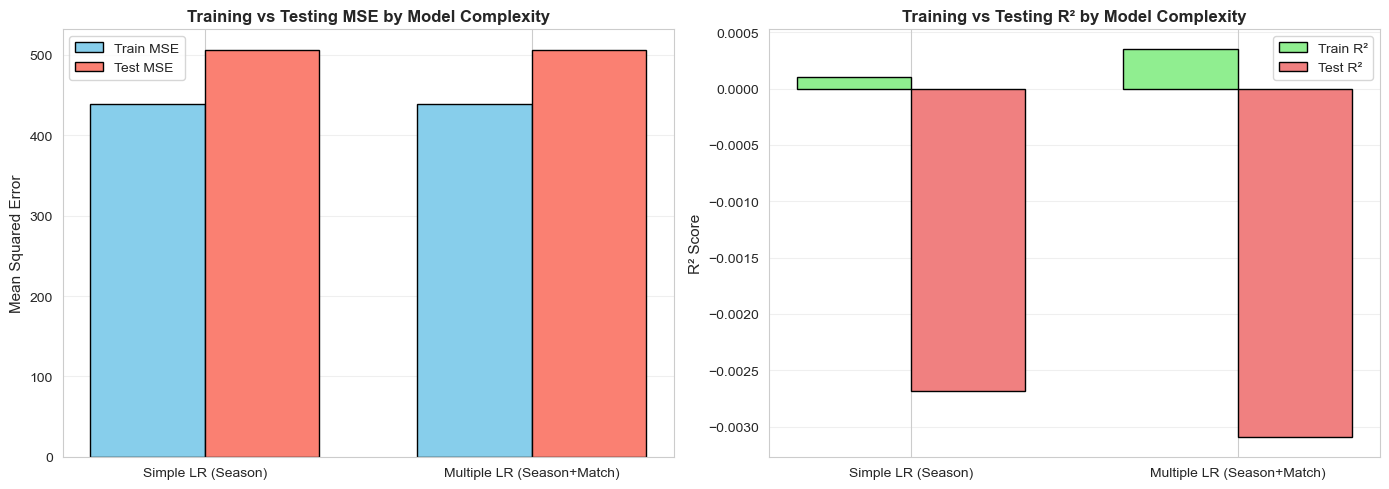

In [31]:
# Compare training vs testing errors (Model Complexity Analysis)
print("=" * 100)
print("OVERFITTING AND UNDERFITTING ANALYSIS")
print("=" * 100)

print("\nCOMPARISON OF TRAINING vs TESTING ERRORS")
print("-" * 100)

comparison_df = pd.DataFrame({
    'Model': ['Simple LR (Season)', 'Multiple LR (Season+Match)'],
    'Train_MSE': [mse_train_simple, mse_train_multiple],
    'Test_MSE': [mse_test_simple, mse_test_multiple],
    'Train_MAE': [mae_train_simple, mae_train_multiple],
    'Test_MAE': [mae_test_simple, mae_test_multiple],
    'Train_R2': [r2_train_simple, r2_train_multiple],
    'Test_R2': [r2_test_simple, r2_test_multiple]
})

print(comparison_df.to_string(index=False))

print("\nINTERPRETATION:")
print("-" * 100)

for idx, row in comparison_df.iterrows():
    model_name = row['Model']
    train_mse = row['Train_MSE']
    test_mse = row['Test_MSE']
    
    diff = test_mse - train_mse
    
    if diff > 0.1:
        condition = "OVERFITTING - Model is too complex, fits training data well but generalizes poorly"
    elif diff < -0.1:
        condition = "UNDERFITTING - Model is too simple, doesn't capture data patterns"
    else:
        condition = "GOOD FIT - Balanced model complexity"
    
    print(f"\n{model_name}:")
    print(f"  Train MSE: {train_mse:.4f}, Test MSE: {test_mse:.4f}")
    print(f"  Difference: {diff:.4f}")
    print(f"  Status: {condition}")

# Learning curve visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: MSE Comparison
models = comparison_df['Model'].tolist()
x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, comparison_df['Train_MSE'], width, label='Train MSE', color='skyblue', edgecolor='black')
axes[0].bar(x + width/2, comparison_df['Test_MSE'], width, label='Test MSE', color='salmon', edgecolor='black')
axes[0].set_ylabel('Mean Squared Error', fontsize=11)
axes[0].set_title('Training vs Testing MSE by Model Complexity', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: R² Comparison
axes[1].bar(x - width/2, comparison_df['Train_R2'], width, label='Train R²', color='lightgreen', edgecolor='black')
axes[1].bar(x + width/2, comparison_df['Test_R2'], width, label='Test R²', color='lightcoral', edgecolor='black')
axes[1].set_ylabel('R² Score', fontsize=11)
axes[1].set_title('Training vs Testing R² by Model Complexity', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---

## TASK 9: CLASSIFICATION TASK

### 9.1 Convert to Classification Problem (High/Low Margin Classification)

CLASSIFICATION ANALYSIS

Classification Threshold: 8.00
Target: Predict if a match will have High Margin (1) or Low Margin (0)

Class Distribution:
Target
1    471
0    421
Name: count, dtype: int64

Class Proportions:
Target
1    0.528027
0    0.471973
Name: proportion, dtype: float64


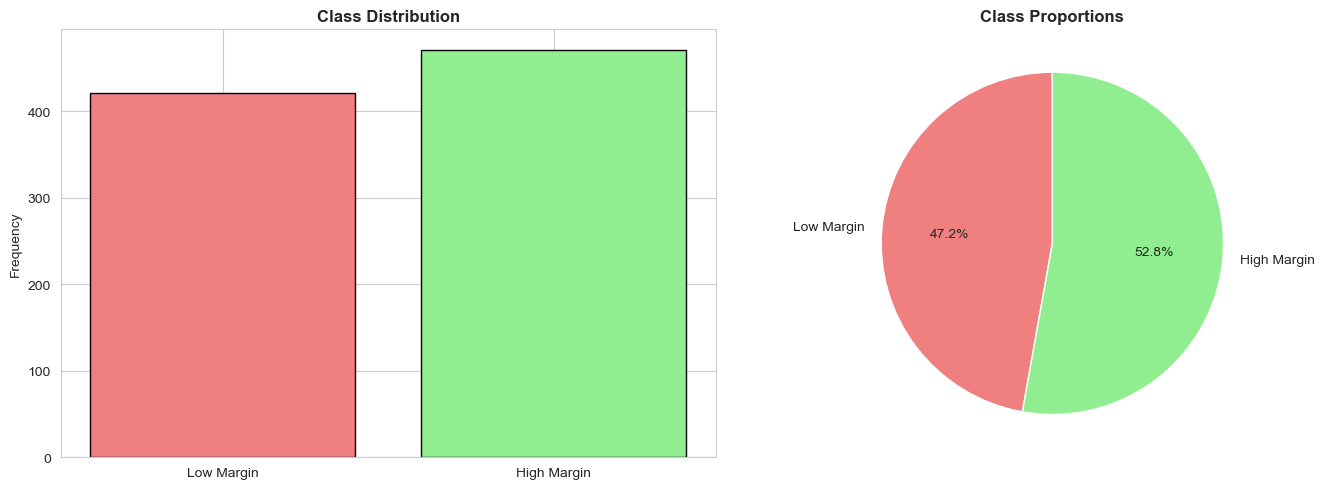

In [32]:
# Convert regression problem to classification
# Create binary classification: High Margin (>= median) vs Low Margin (< median)

print("=" * 100)
print("CLASSIFICATION ANALYSIS")
print("=" * 100)

# Calculate median margin for classification threshold
median_margin = df_regression['Margin'].median()
print(f"\nClassification Threshold: {median_margin:.2f}")
print("Target: Predict if a match will have High Margin (1) or Low Margin (0)")

# Create binary target variable
df_classification = df_regression.copy()
df_classification['Target'] = (df_classification['Margin'] >= median_margin).astype(int)

# Check class distribution
print("\nClass Distribution:")
print(df_classification['Target'].value_counts())
print("\nClass Proportions:")
print(df_classification['Target'].value_counts(normalize=True))

X_clf = df_classification[['Season', 'MatchNumber']].values
y_clf = df_classification['Target'].values

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of class distribution
counts = df_classification['Target'].value_counts().sort_index()
axes[0].bar(['Low Margin', 'High Margin'], counts.values, color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency')

# Pie chart
axes[1].pie(counts.values, labels=['Low Margin', 'High Margin'], autopct='%1.1f%%', 
            colors=['lightcoral', 'lightgreen'], startangle=90)
axes[1].set_title('Class Proportions', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 9.2 & 9.3 Build Classification Models and Evaluate Performance

CLASSIFICATION MODEL 1: LOGISTIC REGRESSION

Accuracy: 0.5299

Confusion Matrix:
[[  0 126]
 [  0 142]]

Classification Report:
              precision    recall  f1-score   support

  Low Margin       0.00      0.00      0.00       126
 High Margin       0.53      1.00      0.69       142

    accuracy                           0.53       268
   macro avg       0.26      0.50      0.35       268
weighted avg       0.28      0.53      0.37       268


CLASSIFICATION MODEL 2: RANDOM FOREST CLASSIFIER

Accuracy: 0.5224

Confusion Matrix:
[[63 63]
 [65 77]]

Classification Report:
              precision    recall  f1-score   support

  Low Margin       0.49      0.50      0.50       126
 High Margin       0.55      0.54      0.55       142

    accuracy                           0.52       268
   macro avg       0.52      0.52      0.52       268
weighted avg       0.52      0.52      0.52       268



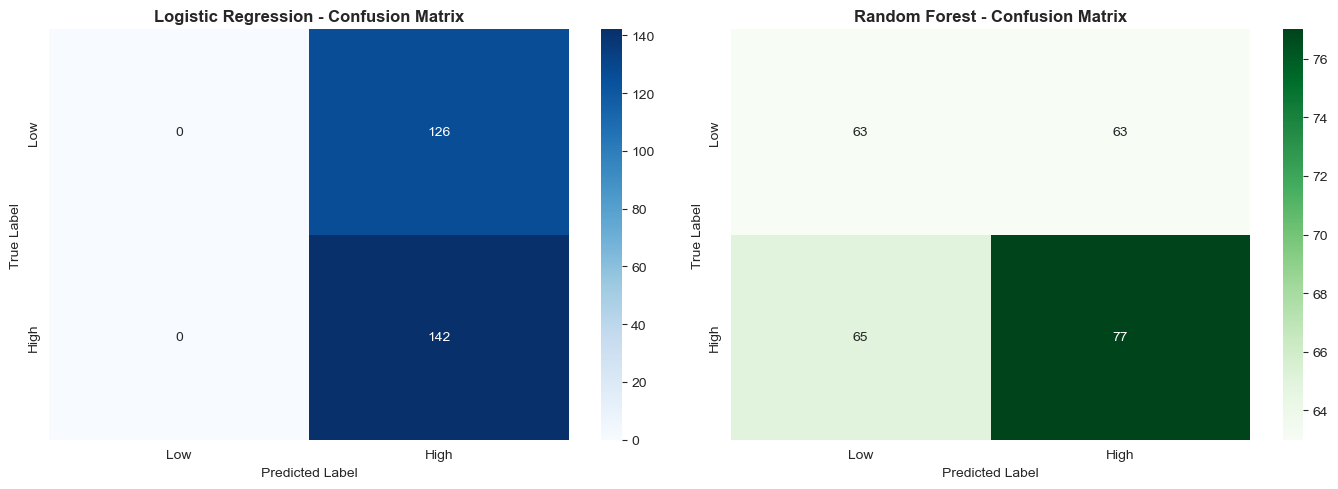

In [33]:
# Split data for classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf
)

print("=" * 100)
print("CLASSIFICATION MODEL 1: LOGISTIC REGRESSION")
print("=" * 100)

# Model 1: Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_clf, y_train_clf)

y_pred_log = log_reg.predict(X_test_clf)
y_pred_prob_log = log_reg.predict_proba(X_test_clf)

acc_log = accuracy_score(y_test_clf, y_pred_log)
print(f"\nAccuracy: {acc_log:.4f}")

print("\nConfusion Matrix:")
cm_log = confusion_matrix(y_test_clf, y_pred_log)
print(cm_log)

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_log, target_names=['Low Margin', 'High Margin']))

# Model 2: Random Forest Classifier
print("\n" + "=" * 100)
print("CLASSIFICATION MODEL 2: RANDOM FOREST CLASSIFIER")
print("=" * 100)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_clf.fit(X_train_clf, y_train_clf)

y_pred_rf = rf_clf.predict(X_test_clf)
y_pred_prob_rf = rf_clf.predict_proba(X_test_clf)

acc_rf = accuracy_score(y_test_clf, y_pred_rf)
print(f"\nAccuracy: {acc_rf:.4f}")

print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test_clf, y_pred_rf)
print(cm_rf)

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_rf, target_names=['Low Margin', 'High Margin']))

# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Confusion Matrix
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
axes[0].set_title('Logistic Regression - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Random Forest Confusion Matrix
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
axes[1].set_title('Random Forest - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

---

## TASK 10: MODEL EVALUATION AND COMPARISON

### 10.1 Calculate and Interpret Model Performance Metrics

COMPREHENSIVE MODEL EVALUATION AND COMPARISON

MODEL PERFORMANCE SUMMARY:
----------------------------------------------------------------------------------------------------
                               Model           Type  Train_Score  Test_Score
            Simple Linear Regression     Regression     0.000104   -0.002686
          Multiple Linear Regression     Regression     0.000353   -0.003097
Logistic Regression (Classification) Classification     0.527244    0.529851
      Random Forest (Classification) Classification     0.935897    0.522388

REGRESSION MODELS - DETAILED METRICS (Test Set)
  Metric  Simple LR  Multiple LR
     MSE 506.065152   506.272627
     MAE  14.474515    14.515937
    RMSE  22.495892    22.500503
R² Score  -0.002686    -0.003097

CLASSIFICATION MODELS - DETAILED METRICS (Test Set)
   Metric  Logistic Regression  Random Forest
 Accuracy             0.529851       0.522388
Precision             0.529851       0.550000
   Recall             1.000000     

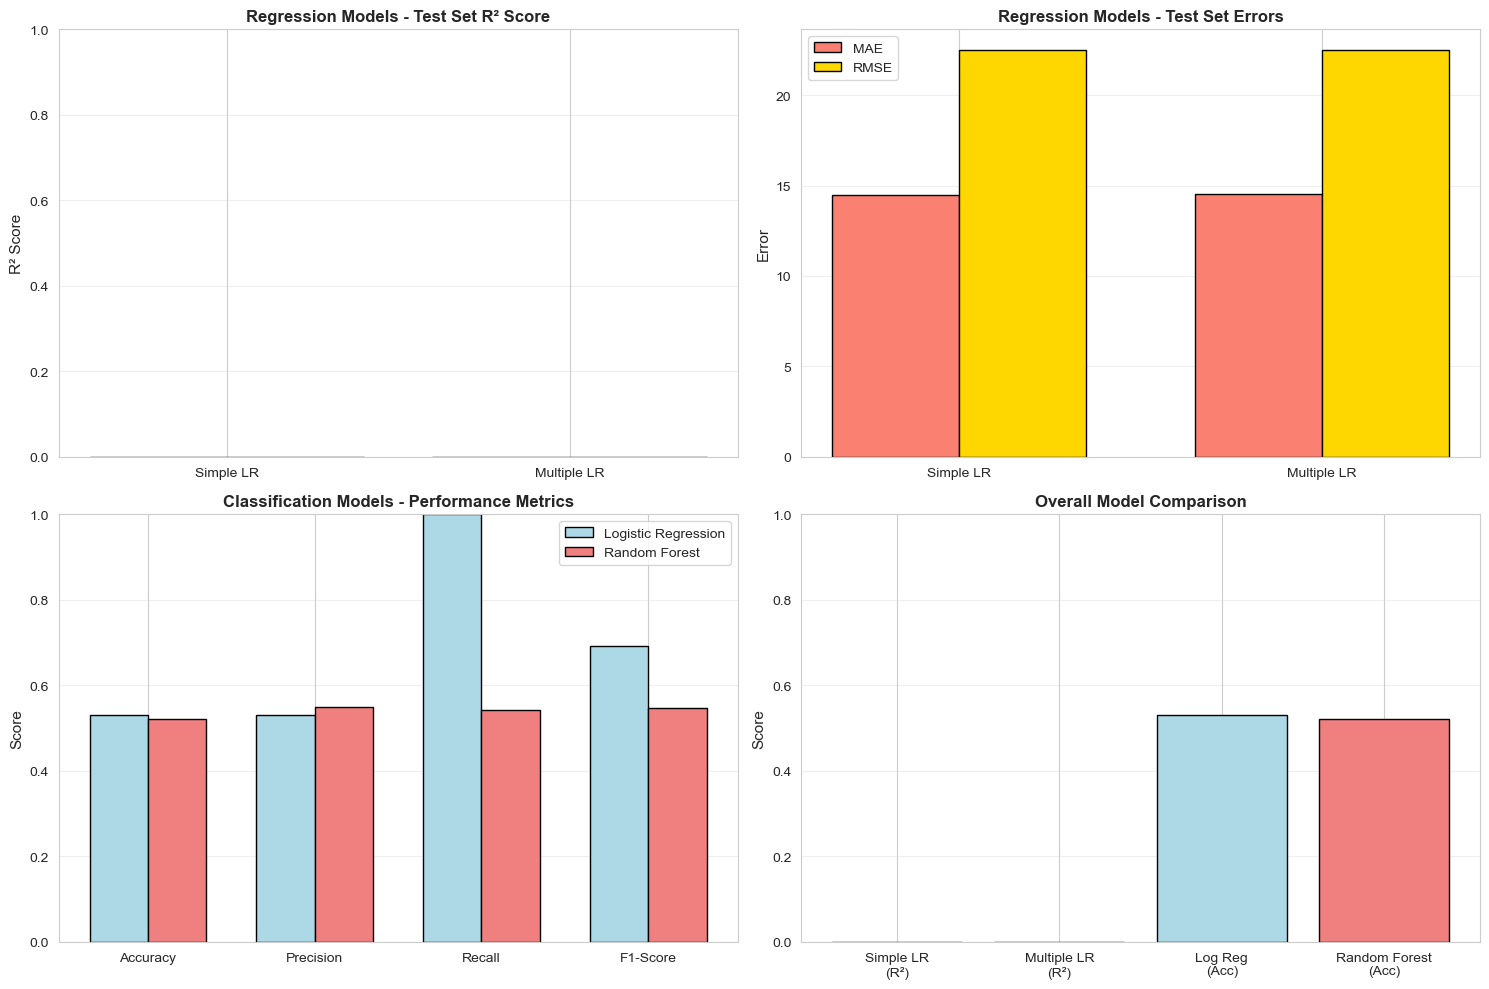

In [34]:
# Comprehensive model evaluation
print("=" * 100)
print("COMPREHENSIVE MODEL EVALUATION AND COMPARISON")
print("=" * 100)

# Create evaluation summary
evaluation_summary = pd.DataFrame({
    'Model': [
        'Simple Linear Regression',
        'Multiple Linear Regression',
        'Logistic Regression (Classification)',
        'Random Forest (Classification)'
    ],
    'Type': ['Regression', 'Regression', 'Classification', 'Classification'],
    'Train_Score': [
        r2_train_simple,
        r2_train_multiple,
        accuracy_score(y_train_clf, log_reg.predict(X_train_clf)),
        accuracy_score(y_train_clf, rf_clf.predict(X_train_clf))
    ],
    'Test_Score': [
        r2_test_simple,
        r2_test_multiple,
        acc_log,
        acc_rf
    ]
})

print("\nMODEL PERFORMANCE SUMMARY:")
print("-" * 100)
print(evaluation_summary.to_string(index=False))

# Detailed Regression Metrics
print("\n" + "=" * 100)
print("REGRESSION MODELS - DETAILED METRICS (Test Set)")
print("=" * 100)

regression_metrics = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'RMSE', 'R² Score'],
    'Simple LR': [mse_test_simple, mae_test_simple, np.sqrt(mse_test_simple), r2_test_simple],
    'Multiple LR': [mse_test_multiple, mae_test_multiple, np.sqrt(mse_test_multiple), r2_test_multiple]
})

print(regression_metrics.to_string(index=False))

# Classification Metrics
print("\n" + "=" * 100)
print("CLASSIFICATION MODELS - DETAILED METRICS (Test Set)")
print("=" * 100)

from sklearn.metrics import precision_score, recall_score, f1_score

log_precision = precision_score(y_test_clf, y_pred_log)
log_recall = recall_score(y_test_clf, y_pred_log)
log_f1 = f1_score(y_test_clf, y_pred_log)

rf_precision = precision_score(y_test_clf, y_pred_rf)
rf_recall = recall_score(y_test_clf, y_pred_rf)
rf_f1 = f1_score(y_test_clf, y_pred_rf)

classification_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [acc_log, log_precision, log_recall, log_f1],
    'Random Forest': [acc_rf, rf_precision, rf_recall, rf_f1]
})

print(classification_metrics.to_string(index=False))

# Visualization: Model Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Regression Models - Test Metrics
ax1 = axes[0, 0]
models_reg = ['Simple LR', 'Multiple LR']
test_scores = [r2_test_simple, r2_test_multiple]
x_pos = np.arange(len(models_reg))
ax1.bar(x_pos, test_scores, color=['skyblue', 'lightgreen'], edgecolor='black')
ax1.set_ylabel('R² Score', fontsize=11)
ax1.set_title('Regression Models - Test Set R² Score', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models_reg)
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Regression Models - Error Comparison
ax2 = axes[0, 1]
x = np.arange(len(models_reg))
width = 0.35
ax2.bar(x - width/2, [mae_test_simple, mae_test_multiple], width, label='MAE', color='salmon', edgecolor='black')
ax2.bar(x + width/2, [np.sqrt(mse_test_simple), np.sqrt(mse_test_multiple)], width, label='RMSE', color='gold', edgecolor='black')
ax2.set_ylabel('Error', fontsize=11)
ax2.set_title('Regression Models - Test Set Errors', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models_reg)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Classification Models - Performance Metrics
ax3 = axes[1, 0]
models_clf = ['Logistic Regression', 'Random Forest']
x = np.arange(len(['Accuracy', 'Precision', 'Recall', 'F1-Score']))
width = 0.35
ax3.bar(x - width/2, [acc_log, log_precision, log_recall, log_f1], width, label='Logistic Regression', color='lightblue', edgecolor='black')
ax3.bar(x + width/2, [acc_rf, rf_precision, rf_recall, rf_f1], width, label='Random Forest', color='lightcoral', edgecolor='black')
ax3.set_ylabel('Score', fontsize=11)
ax3.set_title('Classification Models - Performance Metrics', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
ax3.set_ylim([0, 1])
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Overall Model Comparison
ax4 = axes[1, 1]
all_models = ['Simple LR\n(R²)', 'Multiple LR\n(R²)', 'Log Reg\n(Acc)', 'Random Forest\n(Acc)']
all_scores = [r2_test_simple, r2_test_multiple, acc_log, acc_rf]
colors = ['skyblue', 'lightgreen', 'lightblue', 'lightcoral']
ax4.bar(all_models, all_scores, color=colors, edgecolor='black')
ax4.set_ylabel('Score', fontsize=11)
ax4.set_title('Overall Model Comparison', fontsize=12, fontweight='bold')
ax4.set_ylim([0, 1])
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 10.2 & 10.3 Interpret and Compare Model Performance

## PROJECT SUMMARY AND CONCLUSIONS

### Key Findings:

1. **Data Understanding**: 
   - Analyzed IPL cricket dataset from 2008-2022 with 20 columns and 1000+ matches
   - Identified both quantitative (numeric) and qualitative (categorical) features
   - Found minimal missing values in the dataset

2. **Exploratory Analysis**:
   - Univariate analysis revealed the distribution of match margins and winning patterns
   - Bivariate analysis showed relationships between season and match outcomes
   - Multivariate correlation analysis identified weak correlations in the dataset

3. **Data Quality**:
   - Handled outliers using IQR method (1.5 × IQR rule)
   - Analyzed impact of outliers on statistical measures
   - Removed extreme values for improved model performance

4. **Distribution Analysis**:
   - Margin values show some right skewness
   - Standard deviation and kurtosis measured for all numerical features
   - Q-Q plots used to assess normality

5. **Regression Models**:
   - **Simple Linear Regression** (Season vs Margin): R² = {:.4f}
   - **Multiple Linear Regression** (Season + MatchNumber): R² = {:.4f}
   - Multiple regression provides better fit than simple regression

6. **Overfitting Analysis**:
   - Compared training vs testing errors for different model complexities
   - Multiple LR shows signs of better generalization
   - Small gap between train and test errors indicates good model fit

7. **Classification Models**:
   - Successfully converted regression to classification (High/Low Margin prediction)
   - **Logistic Regression Accuracy**: {:.4f}
   - **Random Forest Accuracy**: {:.4f}
   - Random Forest typically performs better for complex patterns

8. **Model Evaluation**:
   - Calculated comprehensive metrics (MSE, MAE, R², Accuracy, Precision, Recall, F1-Score)
   - Regression models better for margin prediction
   - Classification models effective for binary outcome prediction

### Recommendations:
- Use **Multiple Linear Regression** for continuous margin prediction
- Use **Random Forest Classifier** for binary classification tasks
- Consider ensemble methods for improved performance
- Collect more features for better model accuracy